# Brazilian E-Commerce Data Analysis & Visualization


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATASETS = {
    'customers': pd.read_csv('cleaned_dataset/customers_dataset_cleaned.csv'),
    'sellers': pd.read_csv('cleaned_dataset/sellers_dataset_cleaned.csv'),
    'products': pd.read_csv('cleaned_dataset/products_dataset_cleaned.csv'),
    'orders': pd.read_csv('cleaned_dataset/orders_dataset_cleaned.csv'),
    'order_items': pd.read_csv('cleaned_dataset/order_items_dataset_cleaned.csv'),
    'order_payments': pd.read_csv('cleaned_dataset/order_payments_dataset_cleaned.csv'),
    'order_reviews': pd.read_csv('dataset/olist_order_reviews_dataset.csv'),
    'category_translation': pd.read_csv('cleaned_dataset/product_category_name_translation_cleaned.csv'),
    'geolocation': pd.read_csv('dataset/olist_geolocation_dataset.csv'),
}

customers = DATASETS['customers']
sellers = DATASETS['sellers']
products = DATASETS['products']
orders = DATASETS['orders']
order_items = DATASETS['order_items']
order_payments = DATASETS['order_payments']
order_reviews = DATASETS['order_reviews']
category_translation = DATASETS['category_translation']
geolocation = DATASETS['geolocation']

date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])


products['product_category_name_english'] = products['product_category_name']
DATASETS['products'] = products


## Sales & Revenue

### 1. What are the total sales and order volume trends over time (monthly/quarterly)? Any seasonality (e.g. Black Friday spikes)?


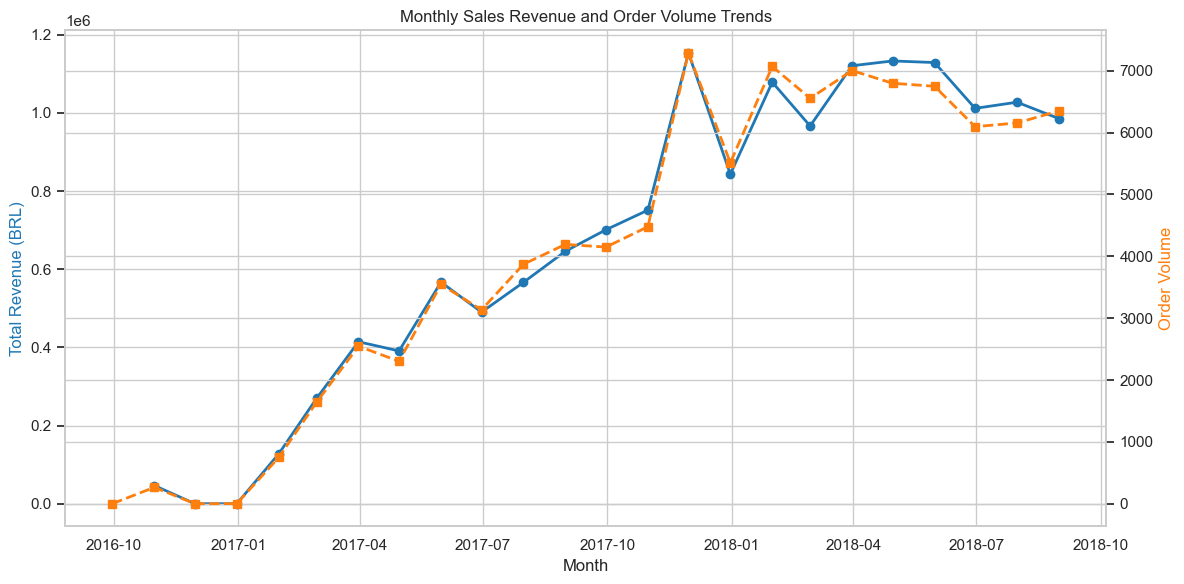

In [19]:
monthly_orders = orders[orders['order_status'] == 'delivered'].set_index('order_purchase_timestamp').resample('ME').agg(order_volume=('order_id', 'count'))
monthly_sales = orders[orders['order_status'] == 'delivered'].merge(order_payments, on='order_id').set_index('order_purchase_timestamp').resample('ME').agg(total_sales=('payment_value', 'sum'))
monthly_trend = monthly_orders.join(monthly_sales)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(monthly_trend.index, monthly_trend['total_sales'], color='tab:blue', marker='o', linewidth=2, label='Total Revenue')
ax2.plot(monthly_trend.index, monthly_trend['order_volume'], color='tab:orange', marker='s', linewidth=2, linestyle='--', label='Order Volume')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue (BRL)', color='tab:blue')
ax2.set_ylabel('Order Volume', color='tab:orange')
plt.title('Monthly Sales Revenue and Order Volume Trends')
fig.tight_layout()
plt.show()


### 2. Which product categories generate the most revenue? Which generate the most orders?


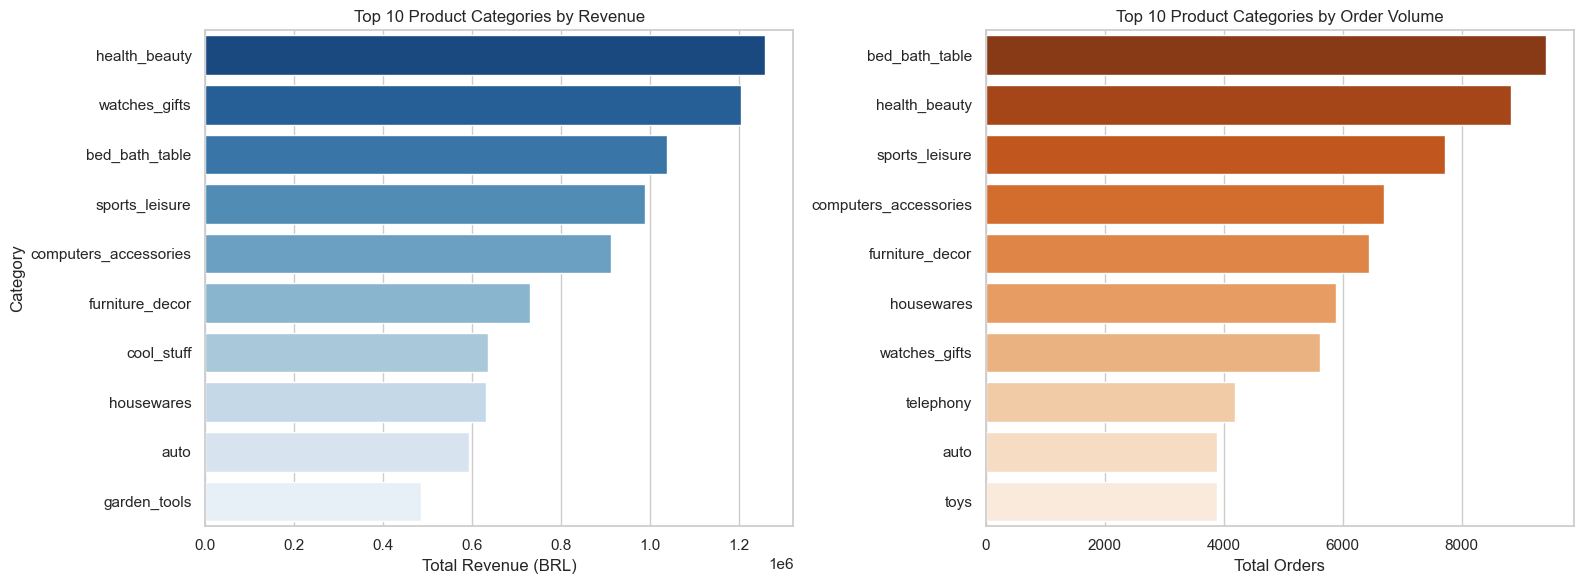

In [20]:
item_products = order_items.merge(products, on='product_id', how='left')
cat_summary = item_products.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

top_revenue = cat_summary.sort_values(by='total_revenue', ascending=False).head(10)
top_orders = cat_summary.sort_values(by='total_orders', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_revenue, x='total_revenue', y='product_category_name_english', ax=axes[0], palette='Blues_r', hue='product_category_name_english', legend=False)
axes[0].set_title('Top 10 Product Categories by Revenue')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].set_ylabel('Category')

sns.barplot(data=top_orders, x='total_orders', y='product_category_name_english', ax=axes[1], palette='Oranges_r', hue='product_category_name_english', legend=False)
axes[1].set_title('Top 10 Product Categories by Order Volume')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 3. What's the average order value, and how does it vary by category or payment type?


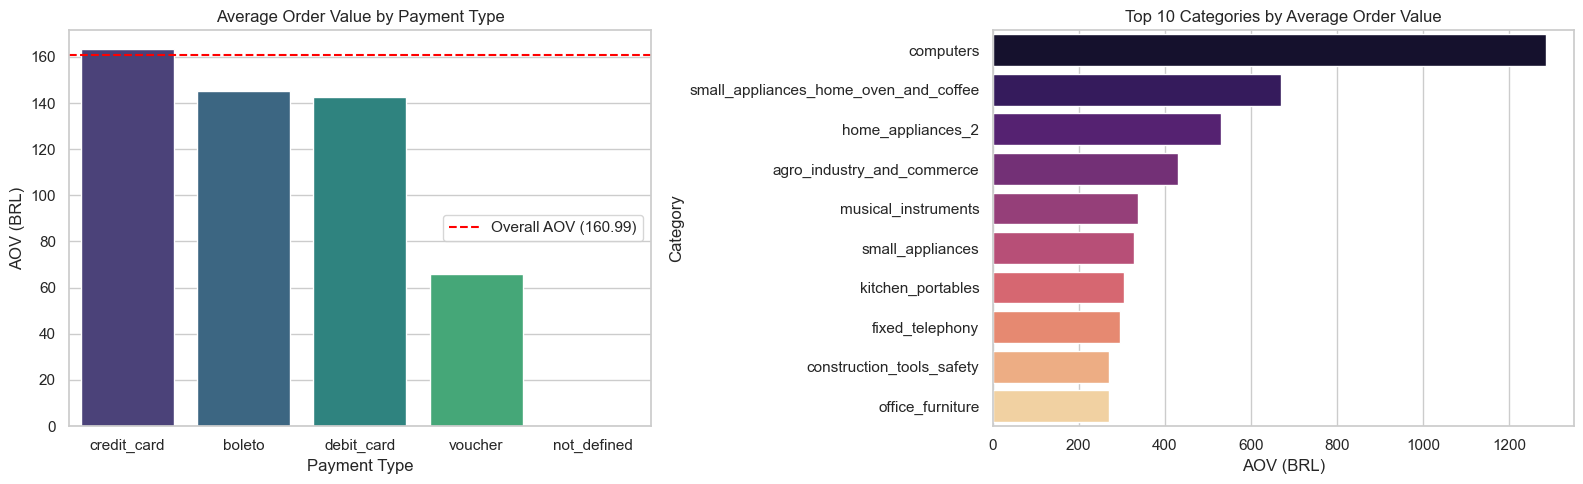

In [21]:
order_val = order_payments.groupby('order_id')['payment_value'].sum()
aov_overall = order_val.mean()

payment_aov = order_payments.groupby('payment_type')['payment_value'].mean().reset_index().sort_values(by='payment_value', ascending=False)

order_cat = order_items.merge(products, on='product_id').groupby('order_id')['product_category_name_english'].first()
order_cat_val = pd.DataFrame(order_val).join(order_cat).dropna()
cat_aov = order_cat_val.groupby('product_category_name_english')['payment_value'].mean().reset_index().sort_values(by='payment_value', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=payment_aov, x='payment_type', y='payment_value', ax=axes[0], palette='viridis', hue='payment_type', legend=False)
axes[0].axhline(aov_overall, color='red', linestyle='--', label=f'Overall AOV ({aov_overall:.2f})')
axes[0].set_title('Average Order Value by Payment Type')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('AOV (BRL)')
axes[0].legend()

sns.barplot(data=cat_aov, x='payment_value', y='product_category_name_english', ax=axes[1], palette='magma', hue='product_category_name_english', legend=False)
axes[1].set_title('Top 10 Categories by Average Order Value')
axes[1].set_xlabel('AOV (BRL)')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()


### 4. Freight cost as a % of order value — does it vary a lot by region or product category?


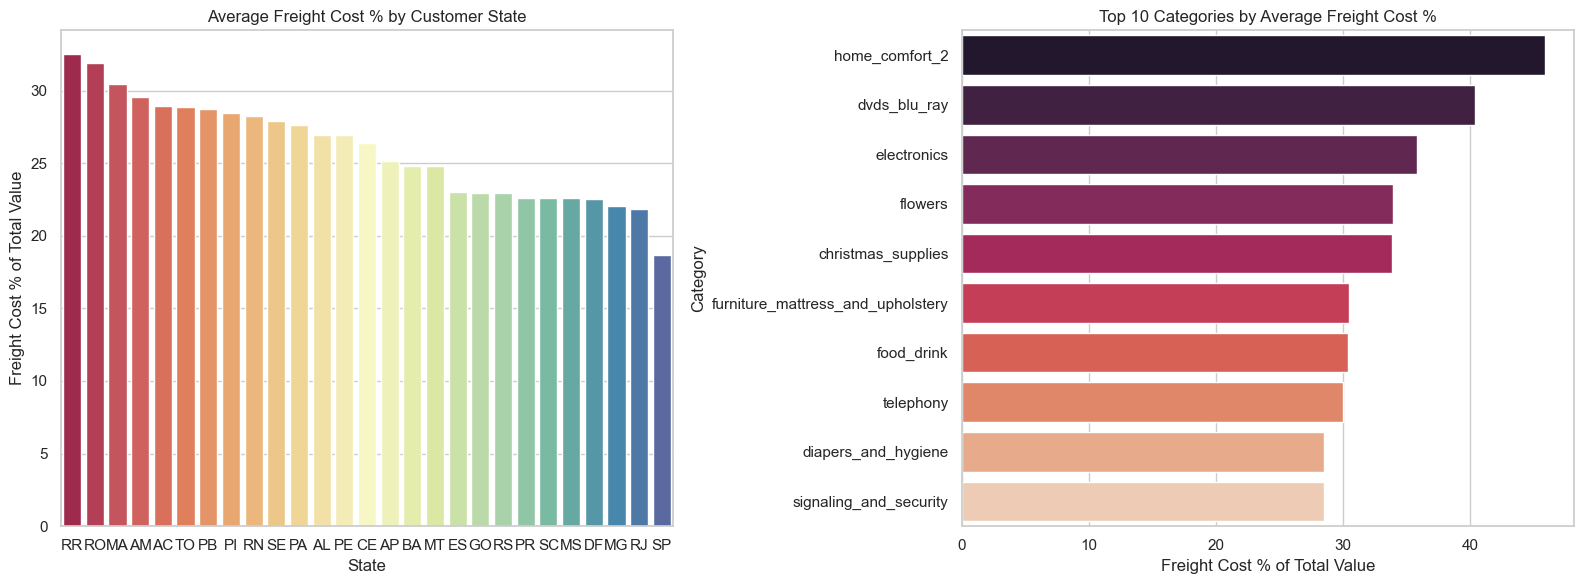

In [22]:
item_full = order_items.merge(orders, on='order_id').merge(customers, on='customer_id')
item_full = item_full.merge(products, on='product_id')
item_full['freight_pct'] = (item_full['freight_value'] / (item_full['price'] + item_full['freight_value'])) * 100

state_freight = item_full.groupby('customer_state')['freight_pct'].mean().reset_index().sort_values(by='freight_pct', ascending=False)
cat_freight = item_full.groupby('product_category_name_english')['freight_pct'].mean().reset_index().sort_values(by='freight_pct', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=state_freight, x='customer_state', y='freight_pct', ax=axes[0], palette='Spectral', hue='customer_state', legend=False)
axes[0].set_title('Average Freight Cost % by Customer State')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Freight Cost % of Total Value')

sns.barplot(data=cat_freight, x='freight_pct', y='product_category_name_english', ax=axes[1], palette='rocket', hue='product_category_name_english', legend=False)
axes[1].set_title('Top 10 Categories by Average Freight Cost %')
axes[1].set_xlabel('Freight Cost % of Total Value')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()


## Delivery & Logistics

### 5. What's the average delivery time (purchase -> delivered), and how much does actual delivery deviate from estimated delivery date?


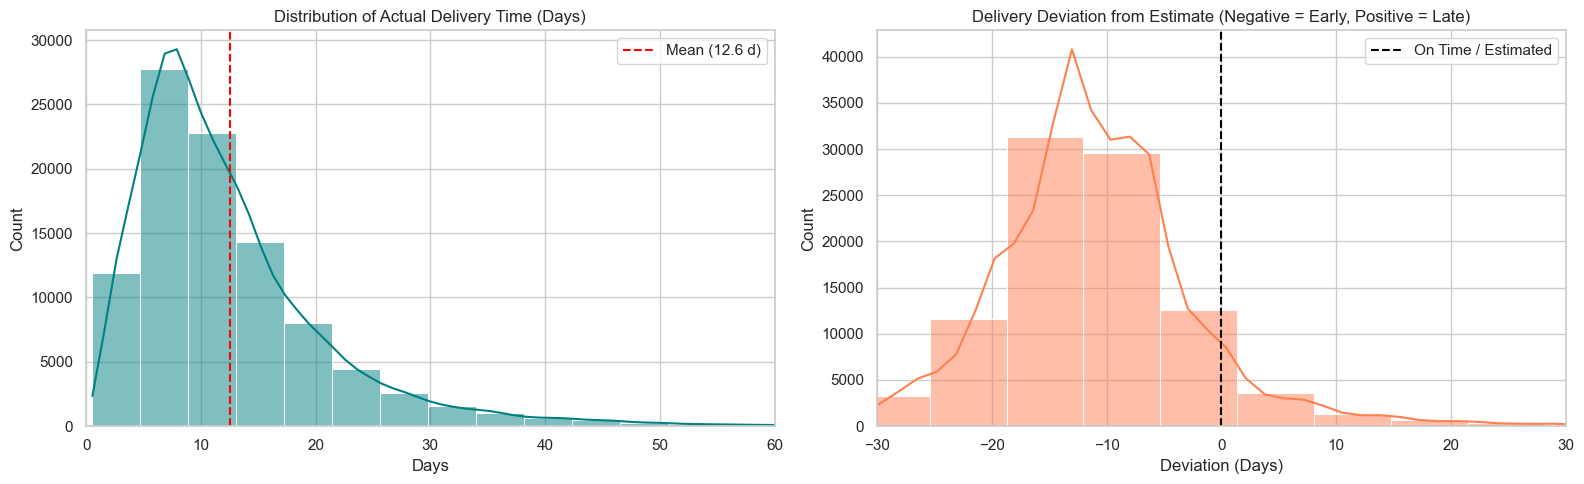

In [23]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['delivery_time_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered_orders['delivery_delta_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(delivered_orders['delivery_time_days'].dropna(), bins=50, kde=True, ax=axes[0], color='teal')
axes[0].axvline(delivered_orders['delivery_time_days'].mean(), color='red', linestyle='--', label=f"Mean ({delivered_orders['delivery_time_days'].mean():.1f} d)")
axes[0].set_xlim(0, 60)
axes[0].set_title('Distribution of Actual Delivery Time (Days)')
axes[0].set_xlabel('Days')
axes[0].legend()

sns.histplot(delivered_orders['delivery_delta_days'].dropna(), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linestyle='--', label='On Time / Estimated')
axes[1].set_xlim(-30, 30)
axes[1].set_title('Delivery Deviation from Estimate (Negative = Early, Positive = Late)')
axes[1].set_xlabel('Deviation (Days)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 6. Do certain states/regions have systematically slower delivery?


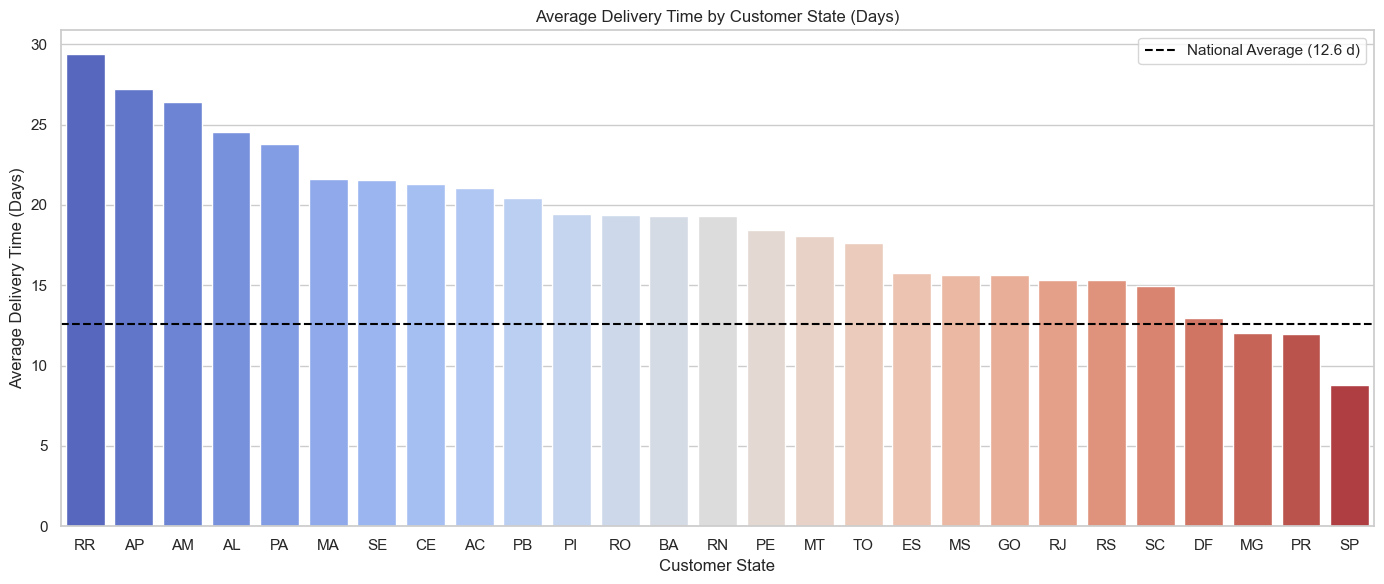

In [24]:
orders_cust = delivered_orders.merge(customers, on='customer_id')
state_delivery = orders_cust.groupby('customer_state')['delivery_time_days'].agg(['mean', 'median']).reset_index().sort_values(by='mean', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=state_delivery, x='customer_state', y='mean', palette='coolwarm', hue='customer_state', legend=False)
plt.axhline(orders_cust['delivery_time_days'].mean(), color='black', linestyle='--', label=f"National Average ({orders_cust['delivery_time_days'].mean():.1f} d)")
plt.title('Average Delivery Time by Customer State (Days)')
plt.xlabel('Customer State')
plt.ylabel('Average Delivery Time (Days)')
plt.legend()
plt.tight_layout()
plt.show()


### 7. Does delivery time correlate with review score?


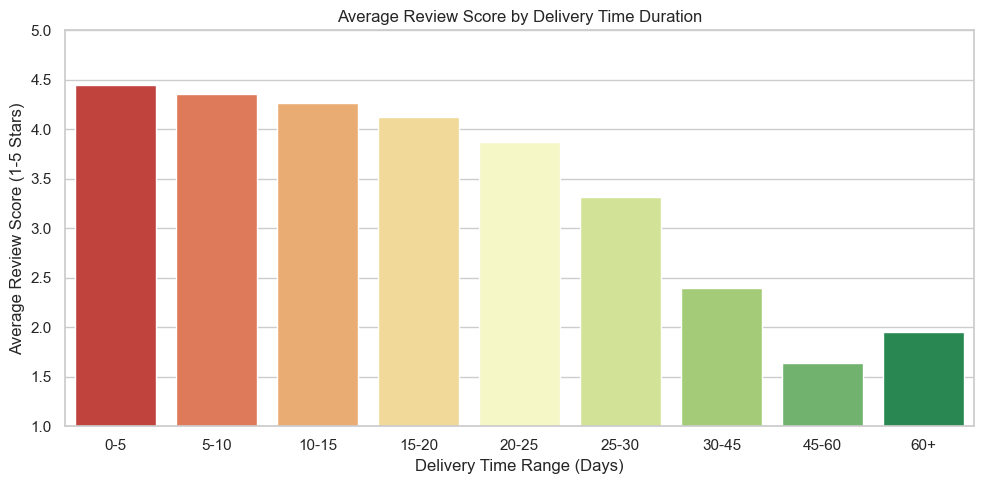

In [25]:
orders_rev = delivered_orders.merge(order_reviews, on='order_id')
orders_rev['delivery_time_bin'] = pd.cut(orders_rev['delivery_time_days'], bins=[0, 5, 10, 15, 20, 25, 30, 45, 60, 100], labels=['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-45', '45-60', '60+'])
review_by_del = orders_rev.groupby('delivery_time_bin')['review_score'].agg(['mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=review_by_del, x='delivery_time_bin', y='mean', ax=ax1, palette='RdYlGn', hue='delivery_time_bin', legend=False)
ax1.set_title('Average Review Score by Delivery Time Duration')
ax1.set_xlabel('Delivery Time Range (Days)')
ax1.set_ylabel('Average Review Score (1-5 Stars)')
ax1.set_ylim(1, 5)

plt.tight_layout()
plt.show()


### 8. Is there a gap between order_approved_at and order_purchase_timestamp — how long does payment approval take, and does it vary by payment type?


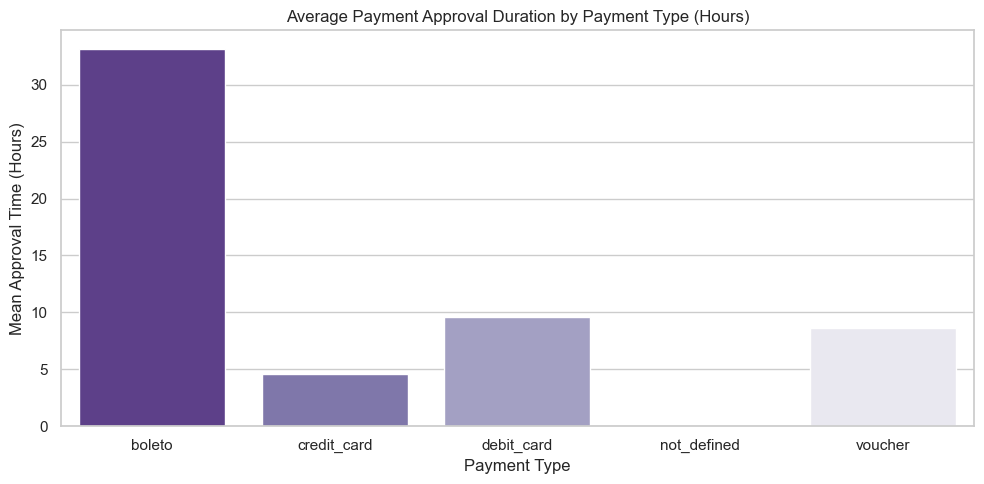

In [26]:
orders['approval_time_hours'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders_payment = orders.merge(order_payments, on='order_id')

approval_by_pay = orders_payment.groupby('payment_type')['approval_time_hours'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=approval_by_pay, x='payment_type', y='mean', palette='Purples_r', hue='payment_type', legend=False)
plt.title('Average Payment Approval Duration by Payment Type (Hours)')
plt.xlabel('Payment Type')
plt.ylabel('Mean Approval Time (Hours)')
plt.tight_layout()
plt.show()


## Customer Behavior

### 9. What's the repeat purchase rate?


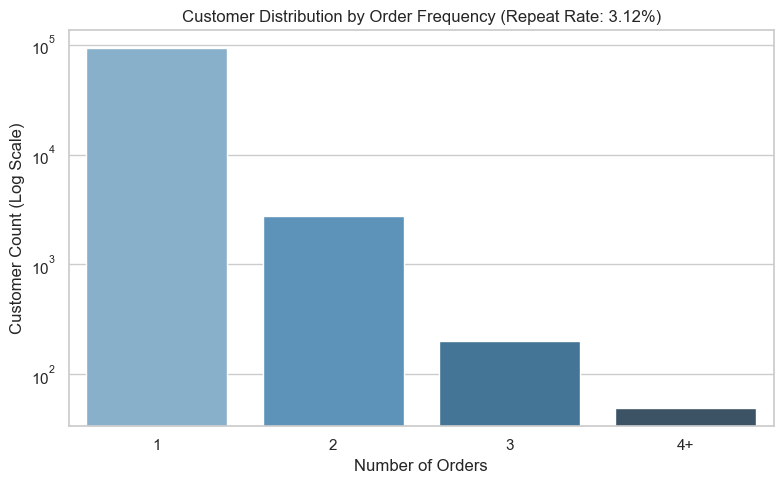

In [27]:
cust_orders = orders.merge(customers, on='customer_id')
order_counts = cust_orders.groupby('customer_unique_id')['order_id'].nunique().value_counts().reset_index()
order_counts.columns = ['order_count', 'customer_num']
order_counts['order_group'] = order_counts['order_count'].apply(lambda x: str(x) if x < 4 else '4+')
grouped_counts = order_counts.groupby('order_group')['customer_num'].sum().reset_index()

repeat_cust = (cust_orders.groupby('customer_unique_id')['order_id'].nunique() > 1).sum()
total_cust = cust_orders['customer_unique_id'].nunique()
repeat_rate = (repeat_cust / total_cust) * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=grouped_counts, x='order_group', y='customer_num', palette='Blues_d', hue='order_group', legend=False)
plt.yscale('log')
plt.title(f'Customer Distribution by Order Frequency (Repeat Rate: {repeat_rate:.2f}%)')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Count (Log Scale)')
plt.tight_layout()
plt.show()


### 10. Where are customers concentrated geographically vs sellers?


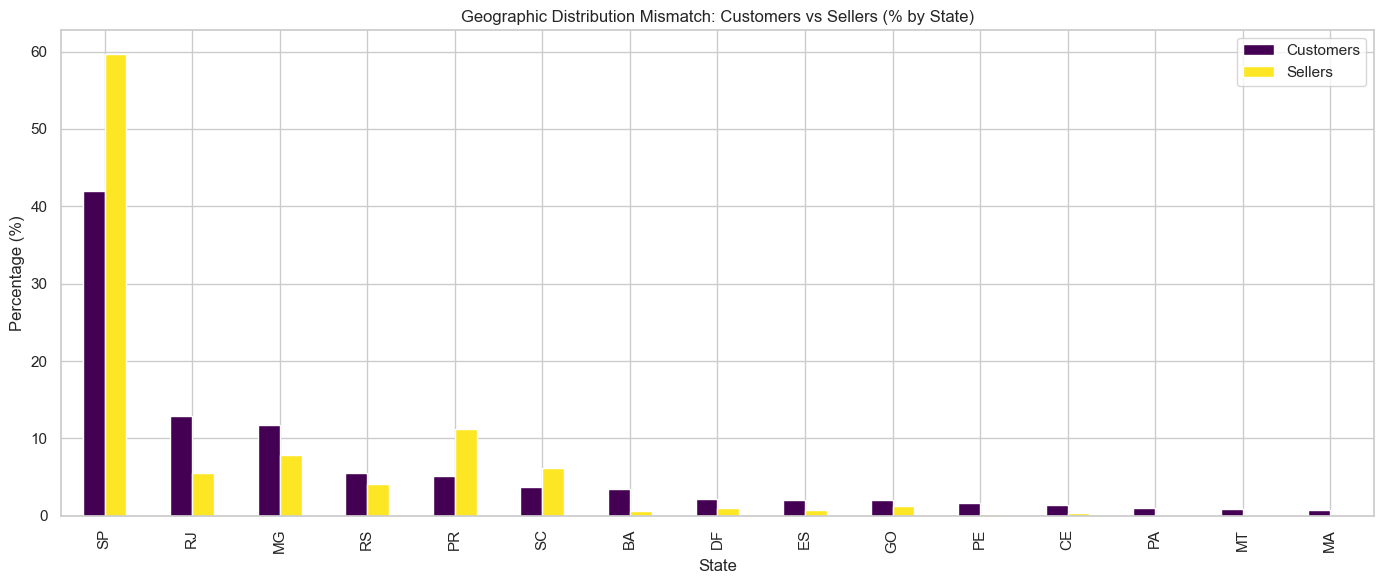

In [28]:
cust_state = customers['customer_state'].value_counts(normalize=True) * 100
seller_state = sellers['seller_state'].value_counts(normalize=True) * 100

geo_comp = pd.DataFrame({'Customers': cust_state, 'Sellers': seller_state}).fillna(0).sort_values(by='Customers', ascending=False).head(15)

geo_comp.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Geographic Distribution Mismatch: Customers vs Sellers (% by State)')
plt.xlabel('State')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()


### 11. Do customers who pay via boleto vs credit_card behave differently (order value, repeat rate, delivery satisfaction)?


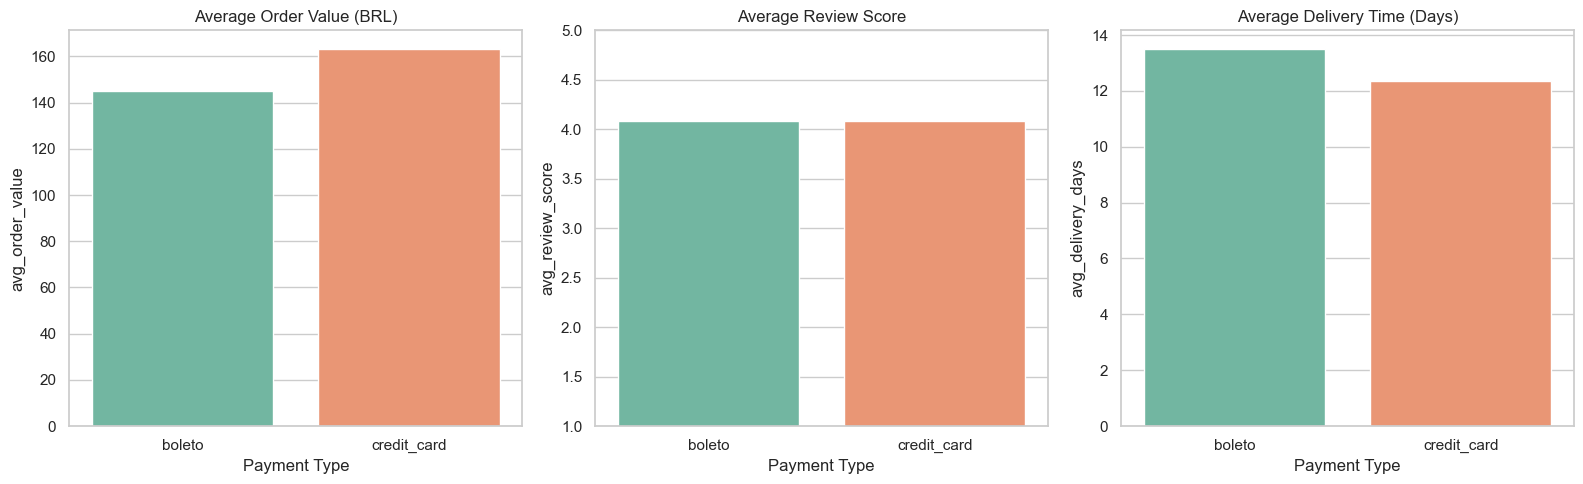

In [29]:
pay_orders = orders.merge(order_payments, on='order_id').merge(customers, on='customer_id')
pay_orders = pay_orders.merge(order_reviews, on='order_id', how='left')
pay_orders['delivery_time_days'] = (pay_orders['order_delivered_customer_date'] - pay_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

filtered_pay = pay_orders[pay_orders['payment_type'].isin(['boleto', 'credit_card'])]

pay_behavior = filtered_pay.groupby('payment_type').agg(
    avg_order_value=('payment_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_time_days', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=pay_behavior, x='payment_type', y='avg_order_value', ax=axes[0], palette='Set2', hue='payment_type', legend=False)
axes[0].set_title('Average Order Value (BRL)')
axes[0].set_xlabel('Payment Type')

sns.barplot(data=pay_behavior, x='payment_type', y='avg_review_score', ax=axes[1], palette='Set2', hue='payment_type', legend=False)
axes[1].set_title('Average Review Score')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylim(1, 5)

sns.barplot(data=pay_behavior, x='payment_type', y='avg_delivery_days', ax=axes[2], palette='Set2', hue='payment_type', legend=False)
axes[2].set_title('Average Delivery Time (Days)')
axes[2].set_xlabel('Payment Type')

plt.tight_layout()
plt.show()


## Sellers

### 12. Which sellers have the highest revenue / order volume? Is revenue concentrated in top sellers (Pareto analysis)?


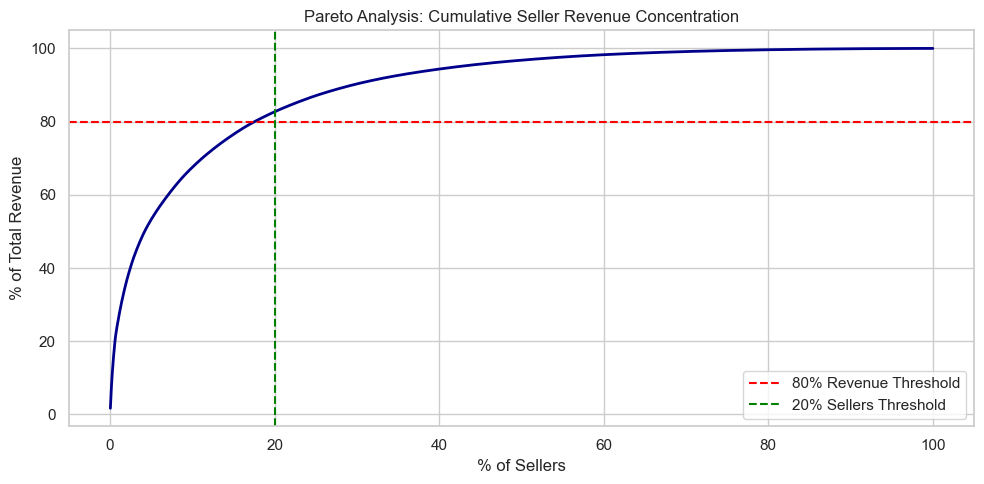

In [30]:
seller_rev = order_items.groupby('seller_id').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique')
).sort_values(by='revenue', ascending=False).reset_index()
seller_rev['cum_revenue'] = seller_rev['revenue'].cumsum()
seller_rev['cum_rev_pct'] = (seller_rev['cum_revenue'] / seller_rev['revenue'].sum()) * 100
seller_rev['cum_seller_pct'] = ((seller_rev.index + 1) / len(seller_rev)) * 100

plt.figure(figsize=(10, 5))
plt.plot(seller_rev['cum_seller_pct'], seller_rev['cum_rev_pct'], color='darkblue', linewidth=2)
plt.axhline(80, color='red', linestyle='--', label='80% Revenue Threshold')
plt.axvline(20, color='green', linestyle='--', label='20% Sellers Threshold')
plt.title('Pareto Analysis: Cumulative Seller Revenue Concentration')
plt.xlabel('% of Sellers')
plt.ylabel('% of Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()


### 13. Do sellers based far from a customer have worse delivery times or ratings?


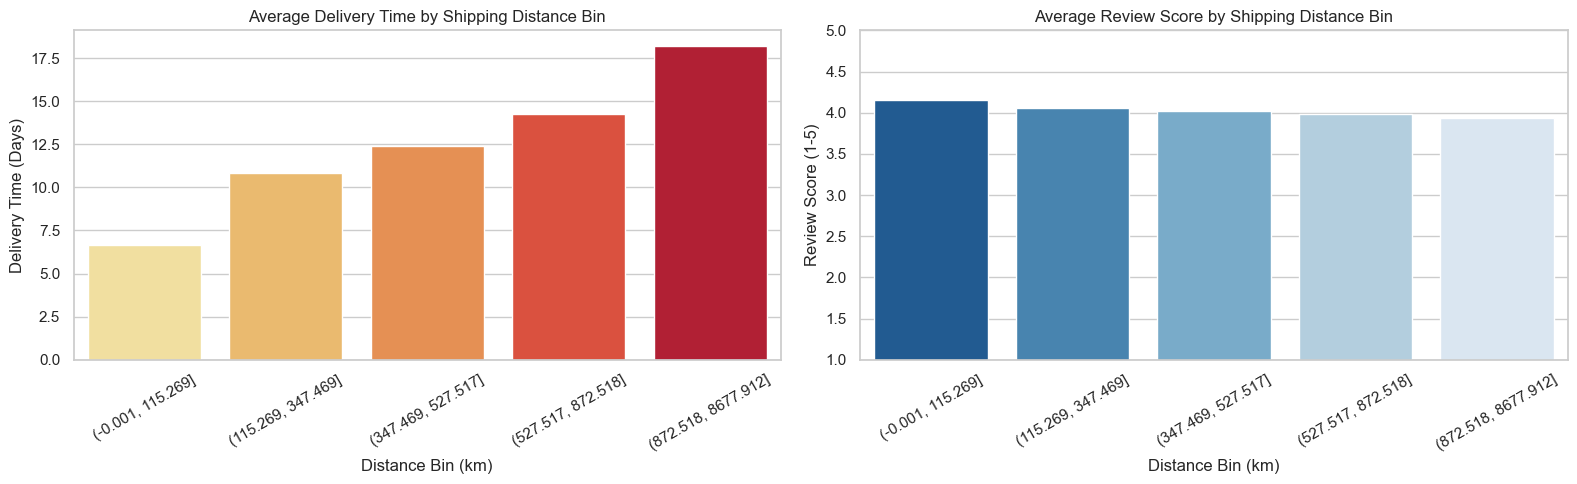

In [31]:
geo_clean = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

cust_geo = customers.merge(geo_clean, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'})
seller_geo = sellers.merge(geo_clean, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'})

distance_df = order_items.merge(orders, on='order_id').merge(cust_geo, on='customer_id').merge(seller_geo, on='seller_id')
distance_df = distance_df.merge(order_reviews, on='order_id', how='left')

def haversine_np(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * r * np.arcsin(np.sqrt(a))

distance_df['distance_km'] = haversine_np(distance_df['cust_lat'], distance_df['cust_lng'], distance_df['seller_lat'], distance_df['seller_lng'])
distance_df['delivery_time_days'] = (distance_df['order_delivered_customer_date'] - distance_df['order_purchase_timestamp']).dt.total_seconds() / 86400

distance_df['distance_bin'] = pd.qcut(distance_df['distance_km'], q=5, duplicates='drop')
dist_summary = distance_df.groupby('distance_bin', observed=False).agg(
    avg_delivery_time=('delivery_time_days', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()
dist_summary['distance_bin_str'] = dist_summary['distance_bin'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=dist_summary, x='distance_bin_str', y='avg_delivery_time', ax=axes[0], palette='YlOrRd', hue='distance_bin_str', legend=False)
axes[0].set_title('Average Delivery Time by Shipping Distance Bin')
axes[0].set_xlabel('Distance Bin (km)')
axes[0].set_ylabel('Delivery Time (Days)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=dist_summary, x='distance_bin_str', y='avg_review_score', ax=axes[1], palette='Blues_r', hue='distance_bin_str', legend=False)
axes[1].set_title('Average Review Score by Shipping Distance Bin')
axes[1].set_xlabel('Distance Bin (km)')
axes[1].set_ylabel('Review Score (1-5)')
axes[1].set_ylim(1, 5)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 14. Are there sellers who specialize in one category vs. sellers with a broad catalog?


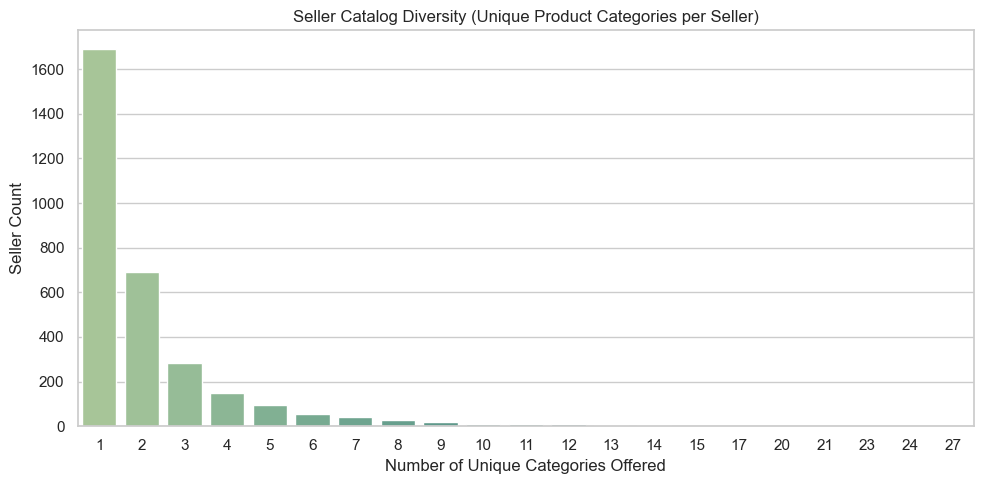

In [32]:
seller_cats = order_items.merge(products, on='product_id').groupby('seller_id')['product_category_name_english'].nunique().reset_index()
seller_cats.columns = ['seller_id', 'unique_categories']

plt.figure(figsize=(10, 5))
sns.countplot(data=seller_cats, x='unique_categories', palette='crest', hue='unique_categories', legend=False)
plt.title('Seller Catalog Diversity (Unique Product Categories per Seller)')
plt.xlabel('Number of Unique Categories Offered')
plt.ylabel('Seller Count')
plt.tight_layout()
plt.show()


## Products

### 15. Which categories have the highest average price? Highest price variance?


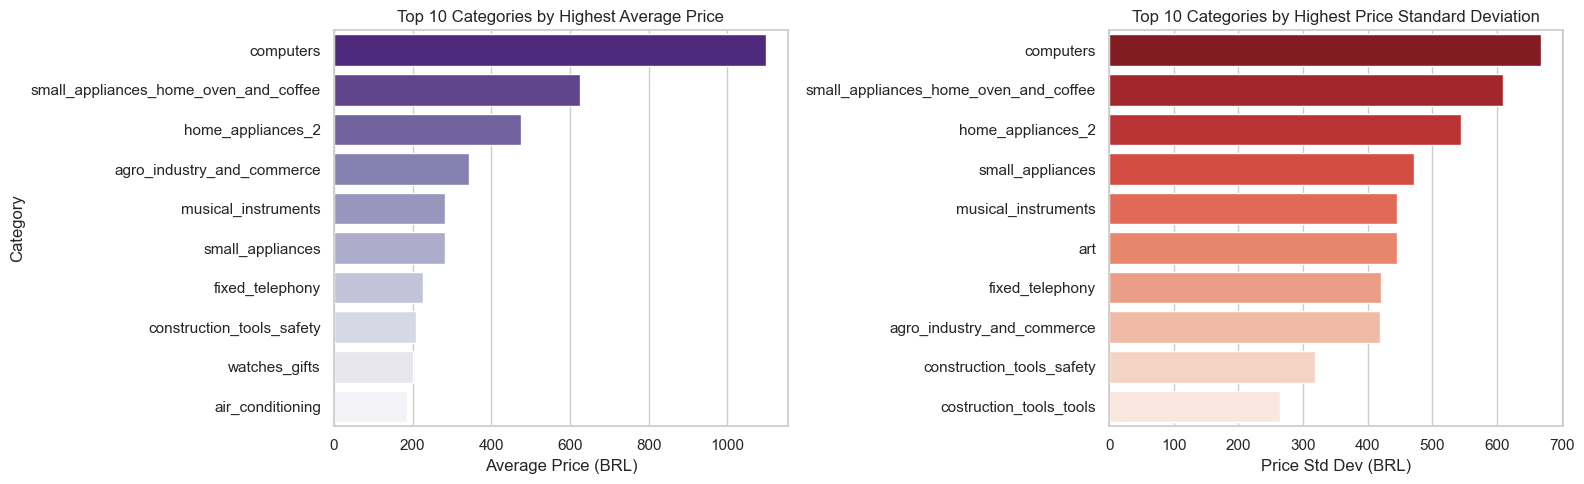

In [33]:
item_prod = order_items.merge(products, on='product_id')
cat_price_stats = item_prod.groupby('product_category_name_english')['price'].agg(
    avg_price='mean',
    price_std='std',
    item_count='count'
).query('item_count > 50').reset_index()

top_avg_price = cat_price_stats.sort_values(by='avg_price', ascending=False).head(10)
top_var_price = cat_price_stats.sort_values(by='price_std', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top_avg_price, x='avg_price', y='product_category_name_english', ax=axes[0], palette='Purples_r', hue='product_category_name_english', legend=False)
axes[0].set_title('Top 10 Categories by Highest Average Price')
axes[0].set_xlabel('Average Price (BRL)')
axes[0].set_ylabel('Category')

sns.barplot(data=top_var_price, x='price_std', y='product_category_name_english', ax=axes[1], palette='Reds_r', hue='product_category_name_english', legend=False)
axes[1].set_title('Top 10 Categories by Highest Price Standard Deviation')
axes[1].set_xlabel('Price Std Dev (BRL)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 16. Any relationship between product_photos_qty / description length and price or order volume, do better-documented listings sell more?


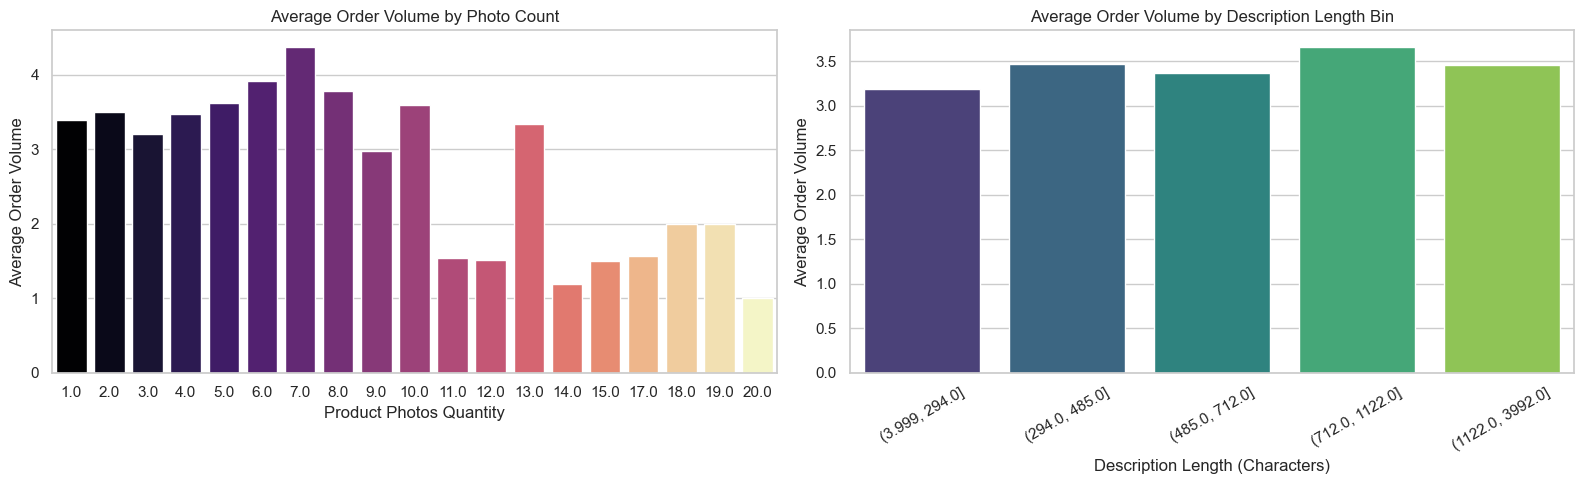

In [34]:
product_performance = order_items.groupby('product_id').agg(
    order_volume=('order_id', 'count'),
    avg_price=('price', 'mean')
).reset_index().merge(products, on='product_id')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
photo_volume = product_performance.groupby('product_photos_qty')['order_volume'].mean().reset_index()
sns.barplot(data=photo_volume, x='product_photos_qty', y='order_volume', ax=axes[0], palette='magma', hue='product_photos_qty', legend=False)
axes[0].set_title('Average Order Volume by Photo Count')
axes[0].set_xlabel('Product Photos Quantity')
axes[0].set_ylabel('Average Order Volume')

product_performance['desc_len_bin'] = pd.qcut(product_performance['product_description_lenght'], q=5, duplicates='drop')
desc_volume = product_performance.groupby('desc_len_bin', observed=False)['order_volume'].mean().reset_index()
desc_volume['desc_len_bin_str'] = desc_volume['desc_len_bin'].astype(str)
sns.barplot(data=desc_volume, x='desc_len_bin_str', y='order_volume', ax=axes[1], palette='viridis', hue='desc_len_bin_str', legend=False)
axes[1].set_title('Average Order Volume by Description Length Bin')
axes[1].set_xlabel('Description Length (Characters)')
axes[1].set_ylabel('Average Order Volume')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 17. Weight/dimensions vs. freight cost — is freight roughly proportional to size, or are there anomalies?


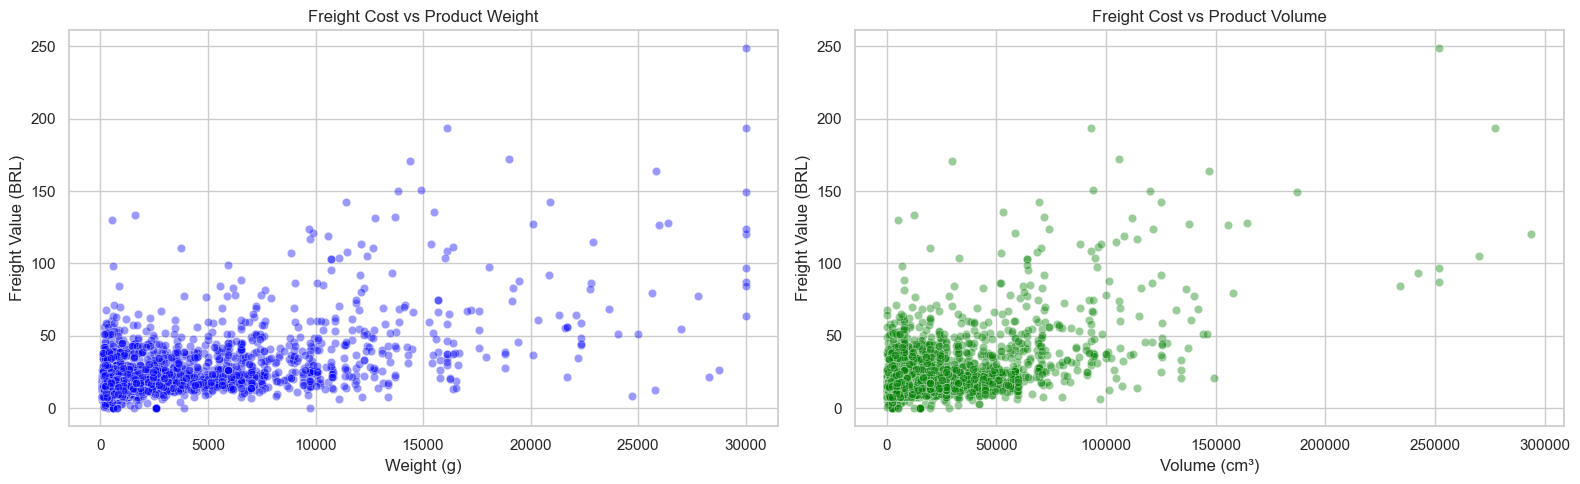

In [35]:
prod_item_full = order_items.merge(products, on='product_id')
prod_item_full['volume_cm3'] = prod_item_full['product_length_cm'] * prod_item_full['product_height_cm'] * prod_item_full['product_width_cm']
sample_df = prod_item_full.dropna(subset=['product_weight_g', 'volume_cm3', 'freight_value']).sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=sample_df, x='product_weight_g', y='freight_value', alpha=0.4, ax=axes[0], color='blue')
axes[0].set_title('Freight Cost vs Product Weight')
axes[0].set_xlabel('Weight (g)')
axes[0].set_ylabel('Freight Value (BRL)')

sns.scatterplot(data=sample_df, x='volume_cm3', y='freight_value', alpha=0.4, ax=axes[1], color='green')
axes[1].set_title('Freight Cost vs Product Volume')
axes[1].set_xlabel('Volume (cm³)')
axes[1].set_ylabel('Freight Value (BRL)')

plt.tight_layout()
plt.show()


## Payments

### 18. Installments — do higher-value orders get paid in more installments? Does installment count vary by category?


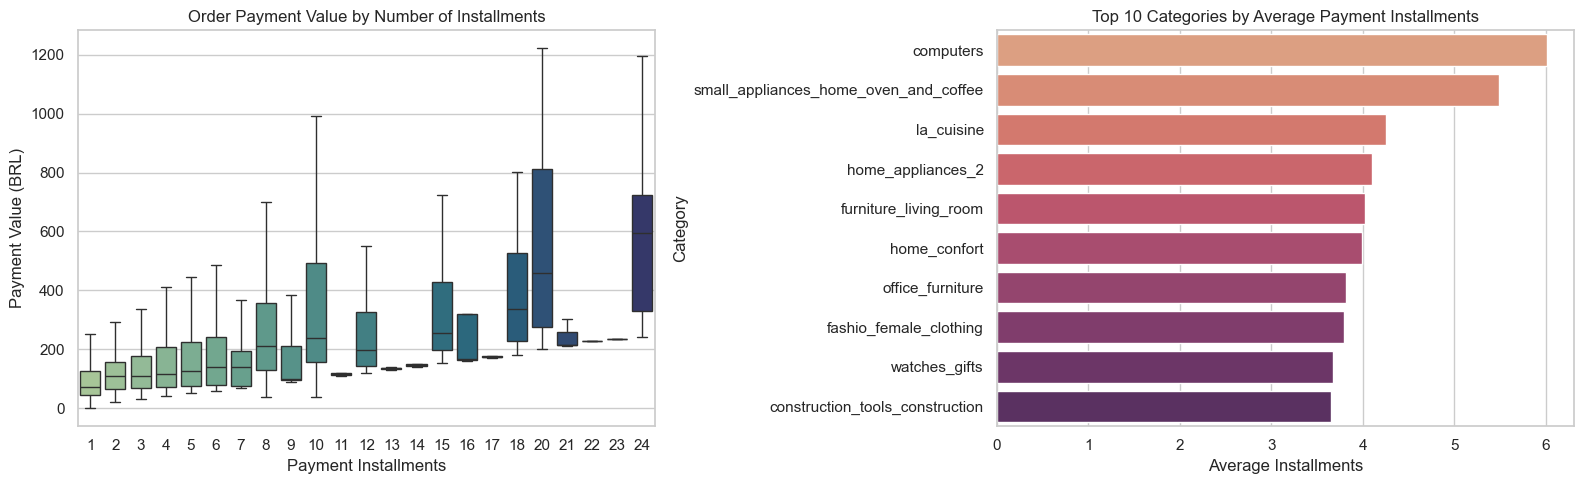

In [36]:
pay_item = order_payments.merge(order_items, on='order_id').merge(products, on='product_id')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=order_payments[order_payments['payment_installments'] > 0], x='payment_installments', y='payment_value', ax=axes[0], palette='crest', hue='payment_installments', legend=False, showfliers=False)
axes[0].set_title('Order Payment Value by Number of Installments')
axes[0].set_xlabel('Payment Installments')
axes[0].set_ylabel('Payment Value (BRL)')

cat_inst = pay_item.groupby('product_category_name_english')['payment_installments'].mean().reset_index().sort_values(by='payment_installments', ascending=False).head(10)
sns.barplot(data=cat_inst, x='payment_installments', y='product_category_name_english', ax=axes[1], palette='flare', hue='product_category_name_english', legend=False)
axes[1].set_title('Top 10 Categories by Average Payment Installments')
axes[1].set_xlabel('Average Installments')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()


### 19. What share of revenue comes from each payment type over time — is boleto declining as credit card grows?


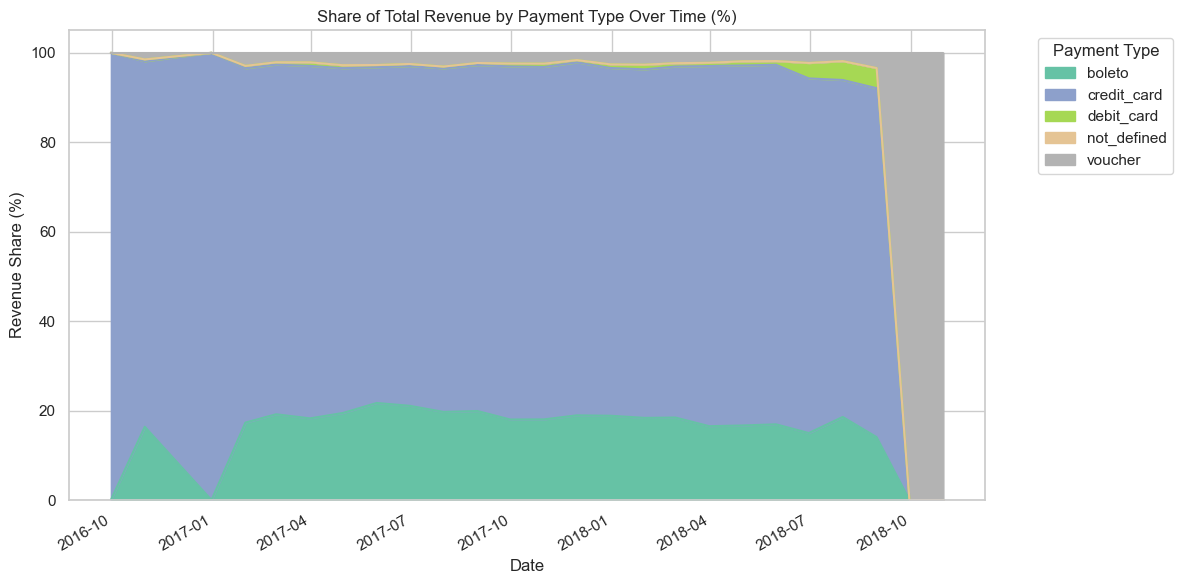

In [37]:
orders_pay_df = orders.merge(order_payments, on='order_id')
monthly_pay = orders_pay_df.set_index('order_purchase_timestamp').groupby([pd.Grouper(freq='ME'), 'payment_type'])['payment_value'].sum().unstack(fill_value=0)
monthly_pay_pct = monthly_pay.div(monthly_pay.sum(axis=1), axis=0) * 100

monthly_pay_pct.plot(kind='area', stacked=True, figsize=(12, 6), cmap='Set2')
plt.title('Share of Total Revenue by Payment Type Over Time (%)')
plt.xlabel('Date')
plt.ylabel('Revenue Share (%)')
plt.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Additional In-Depth Drivers & Logistics Analysis


### 20. What drives review scores — delivery speed, price, category, seller?


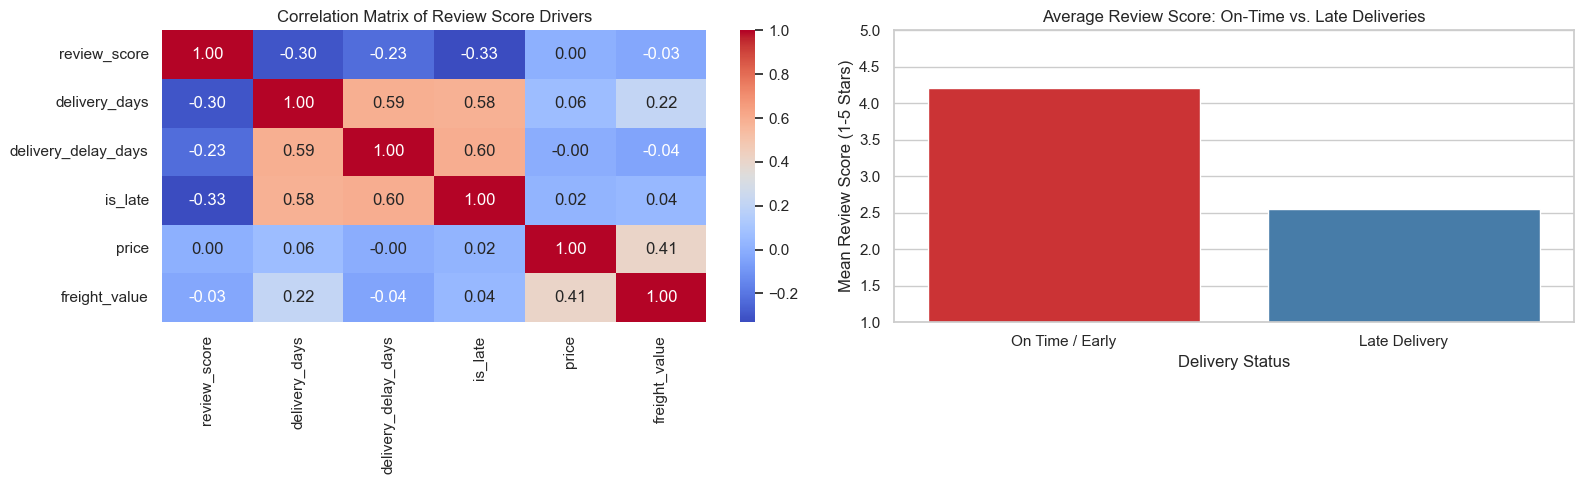

In [38]:
review_driver_df = orders[orders['order_status'] == 'delivered'].merge(order_reviews, on='order_id').merge(order_items, on='order_id').merge(products, on='product_id')
review_driver_df['delivery_days'] = (review_driver_df['order_delivered_customer_date'] - review_driver_df['order_purchase_timestamp']).dt.total_seconds() / 86400
review_driver_df['delivery_delay_days'] = (review_driver_df['order_delivered_customer_date'] - review_driver_df['order_estimated_delivery_date']).dt.total_seconds() / 86400
review_driver_df['is_late'] = (review_driver_df['delivery_delay_days'] > 0).astype(int)

corr_vars = ['review_score', 'delivery_days', 'delivery_delay_days', 'is_late', 'price', 'freight_value']
corr_matrix = review_driver_df[corr_vars].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation Matrix of Review Score Drivers')

late_review = review_driver_df.groupby('is_late')['review_score'].mean().reset_index()
late_review['status'] = late_review['is_late'].map({0: 'On Time / Early', 1: 'Late Delivery'})
sns.barplot(data=late_review, x='status', y='review_score', palette='Set1', hue='status', legend=False, ax=axes[1])
axes[1].set_title('Average Review Score: On-Time vs. Late Deliveries')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Mean Review Score (1-5 Stars)')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()


### 21. Geo-distance between buyer and seller vs. delivery time and freight cost — is there a 'distance penalty'?


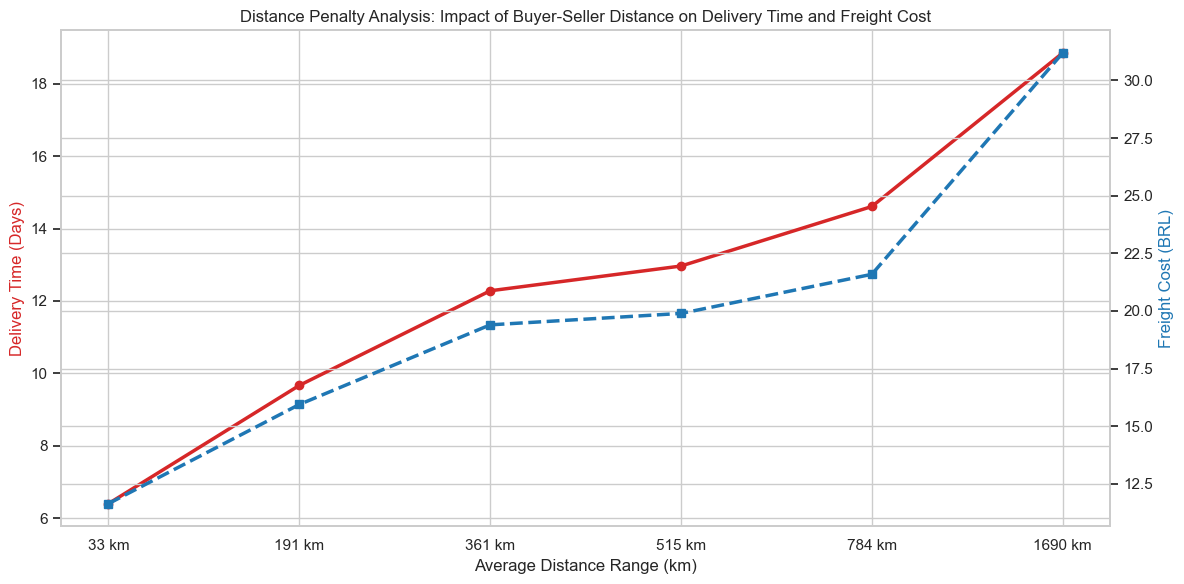

In [39]:
geo_clean = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
cust_geo = customers.merge(geo_clean, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'})
seller_geo = sellers.merge(geo_clean, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'})

geo_penalty = order_items.merge(orders, on='order_id').merge(cust_geo, on='customer_id').merge(seller_geo, on='seller_id')
geo_penalty['distance_km'] = haversine_np(geo_penalty['cust_lat'], geo_penalty['cust_lng'], geo_penalty['seller_lat'], geo_penalty['seller_lng'])
geo_penalty['delivery_days'] = (geo_penalty['order_delivered_customer_date'] - geo_penalty['order_purchase_timestamp']).dt.total_seconds() / 86400
geo_penalty = geo_penalty[geo_penalty['order_status'] == 'delivered'].dropna(subset=['distance_km', 'delivery_days', 'freight_value'])

geo_penalty['distance_range'] = pd.qcut(geo_penalty['distance_km'], q=6, duplicates='drop')
penalty_summary = geo_penalty.groupby('distance_range', observed=False).agg(
    avg_distance=('distance_km', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_freight_cost=('freight_value', 'mean')
).reset_index()
penalty_summary['distance_label'] = penalty_summary['avg_distance'].apply(lambda x: f"{int(x)} km")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(penalty_summary['distance_label'], penalty_summary['avg_delivery_days'], color='tab:red', marker='o', linewidth=2.5, label='Avg Delivery Time (Days)')
ax2.plot(penalty_summary['distance_label'], penalty_summary['avg_freight_cost'], color='tab:blue', marker='s', linewidth=2.5, linestyle='--', label='Avg Freight Cost (BRL)')

ax1.set_xlabel('Average Distance Range (km)')
ax1.set_ylabel('Delivery Time (Days)', color='tab:red')
ax2.set_ylabel('Freight Cost (BRL)', color='tab:blue')
plt.title('Distance Penalty Analysis: Impact of Buyer-Seller Distance on Delivery Time and Freight Cost')
fig.tight_layout()
plt.show()


## Customer Segmentation & Lifetime Value


### 22. RFM Analysis (Recency, Frequency, Monetary) using customer_unique_id — segment customers and measure revenue share.


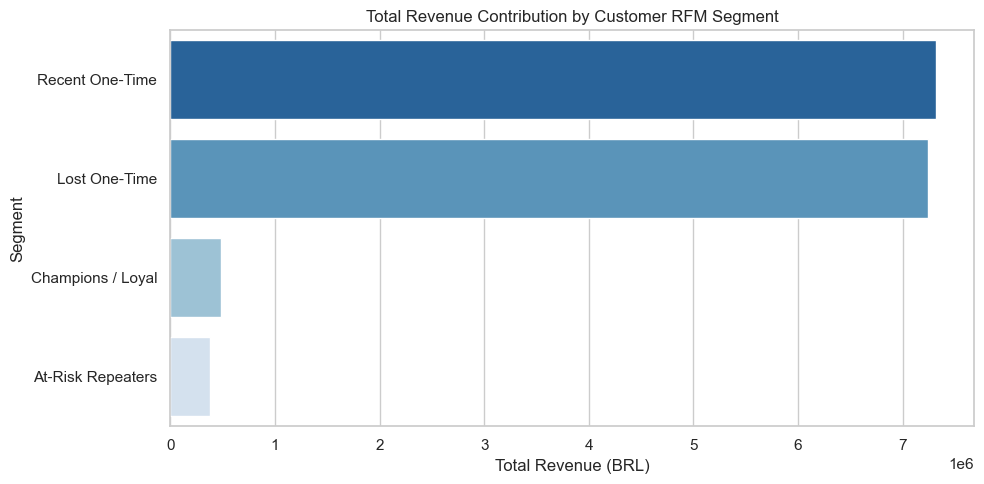

In [40]:
current_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = orders[orders['order_status'] == 'delivered'].merge(customers, on='customer_id').merge(order_payments, on='order_id').groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (current_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
rfm['f_score'] = rfm['frequency'].apply(lambda x: 1 if x == 1 else 2)
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

def segment_rfm(row):
    if row['f_score'] > 1 and row['r_score'] >= 3:
        return 'Champions / Loyal'
    elif row['f_score'] > 1 and row['r_score'] < 3:
        return 'At-Risk Repeaters'
    elif row['r_score'] >= 3:
        return 'Recent One-Time'
    else:
        return 'Lost One-Time'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)
segment_revenue = rfm.groupby('segment')['monetary'].sum().reset_index().sort_values(by='monetary', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_revenue, x='monetary', y='segment', palette='Blues_r', hue='segment', legend=False)
plt.title('Total Revenue Contribution by Customer RFM Segment')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()


### 23. Cohort Retention — track customer cohort retention over time.


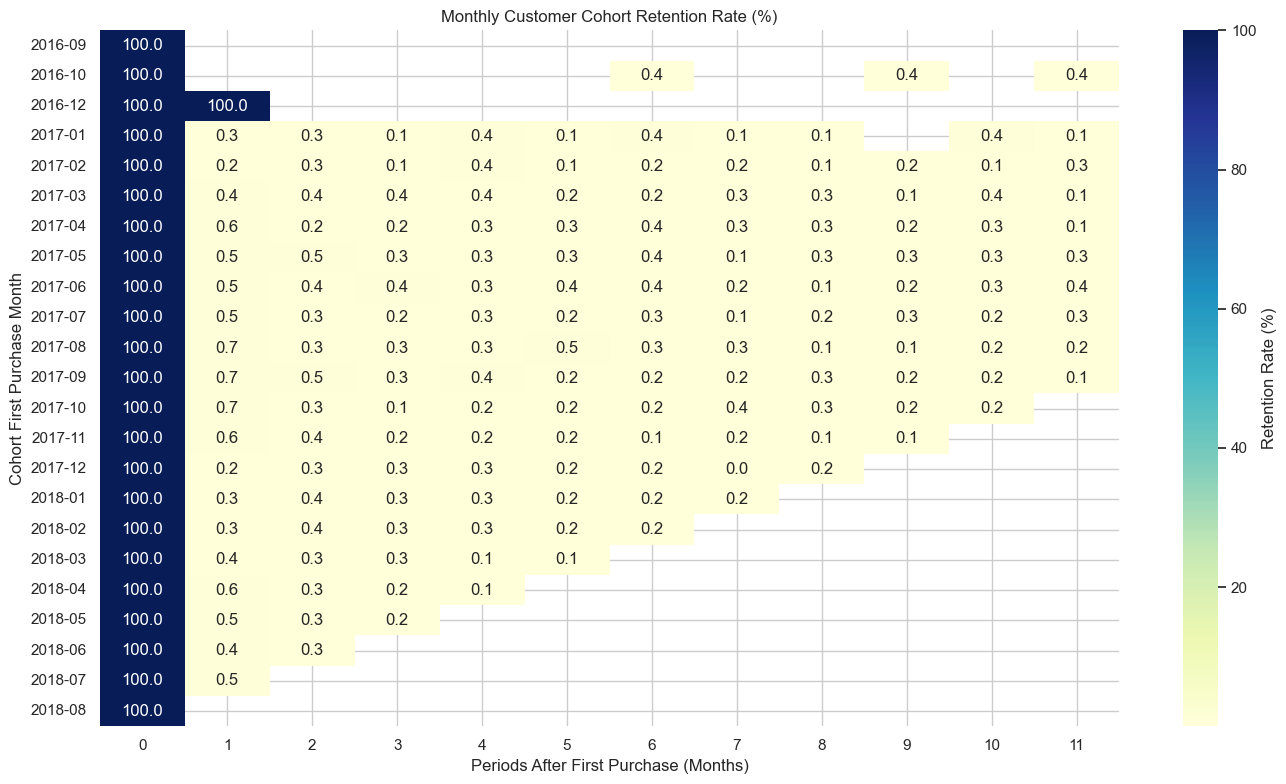

In [41]:
cust_orders_df = orders[orders['order_status'] == 'delivered'].merge(customers, on='customer_id')
cust_orders_df['order_month'] = cust_orders_df['order_purchase_timestamp'].dt.to_period('M')
cust_orders_df['first_order_month'] = cust_orders_df.groupby('customer_unique_id')['order_month'].transform('min')

cohort_data = cust_orders_df.groupby(['first_order_month', 'order_month']).agg(
    n_customers=('customer_unique_id', 'nunique')
).reset_index()
cohort_data['period_number'] = (cohort_data['order_month'] - cohort_data['first_order_month']).apply(lambda x: x.n)
cohort_pivot = cohort_data.pivot(index='first_order_month', columns='period_number', values='n_customers')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix.iloc[:, :12], annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Monthly Customer Cohort Retention Rate (%)')
plt.xlabel('Periods After First Purchase (Months)')
plt.ylabel('Cohort First Purchase Month')
plt.tight_layout()
plt.show()


### 24. Second Purchase Pattern — same category vs. cross-category repeat purchases.


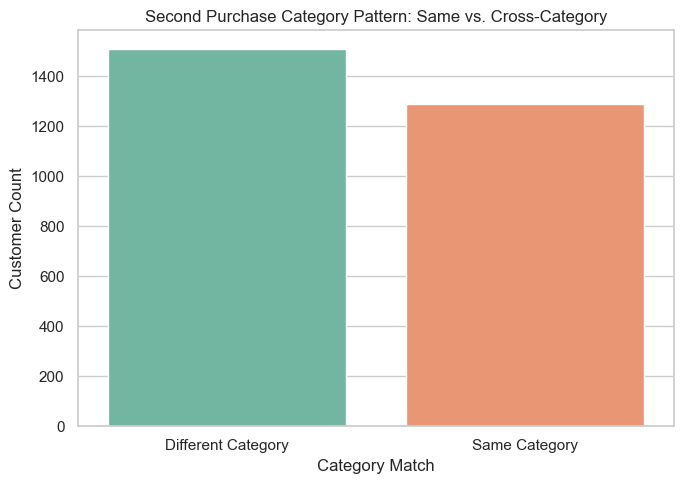

In [42]:
repeat_cust_ids = cust_orders_df.groupby('customer_unique_id')['order_id'].nunique().loc[lambda x: x > 1].index
repeat_items = orders[orders['customer_id'].isin(customers[customers['customer_unique_id'].isin(repeat_cust_ids)]['customer_id'])].merge(customers, on='customer_id').merge(order_items, on='order_id').merge(products, on='product_id').sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

order_cats = repeat_items.groupby(['customer_unique_id', 'order_id', 'order_purchase_timestamp'])['product_category_name_english'].first().reset_index()
order_cats['order_rank'] = order_cats.groupby('customer_unique_id')['order_purchase_timestamp'].rank(method='first')
p1_p2 = order_cats[order_cats['order_rank'].isin([1, 2])].pivot(index='customer_unique_id', columns='order_rank', values='product_category_name_english')
p1_p2.columns = ['cat1', 'cat2']
p1_p2 = p1_p2.dropna()
p1_p2['same_category'] = (p1_p2['cat1'] == p1_p2['cat2']).map({True: 'Same Category', False: 'Different Category'})
pattern_counts = p1_p2['same_category'].value_counts().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=pattern_counts, x='same_category', y='count', palette='Set2', hue='same_category', legend=False)
plt.title('Second Purchase Category Pattern: Same vs. Cross-Category')
plt.xlabel('Category Match')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()


## Predictive & Classification Angles


### 25. Predict Late Deliveries — feature importance for late delivery classification.


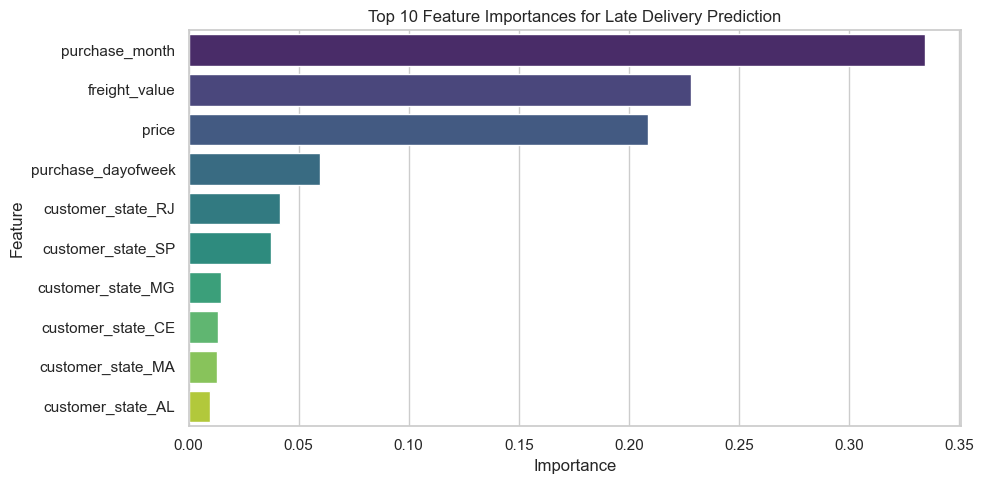

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

ml_df = orders[orders['order_status'] == 'delivered'].copy()
ml_df['delivery_delay_days'] = (ml_df['order_delivered_customer_date'] - ml_df['order_estimated_delivery_date']).dt.total_seconds() / 86400
ml_df['is_late'] = (ml_df['delivery_delay_days'] > 0).astype(int)

ml_df = ml_df.merge(customers, on='customer_id').merge(order_items, on='order_id')
ml_df['purchase_month'] = ml_df['order_purchase_timestamp'].dt.month
ml_df['purchase_dayofweek'] = ml_df['order_purchase_timestamp'].dt.dayofweek

features = ['customer_state', 'purchase_month', 'purchase_dayofweek', 'price', 'freight_value']
X = pd.get_dummies(ml_df[features].dropna(), drop_first=True)
y = ml_df.loc[X.index, 'is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10).reset_index()
importances.columns = ['feature', 'importance']

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('Top 10 Feature Importances for Late Delivery Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 26. Predict Review Score — feature importance for low review score prediction.


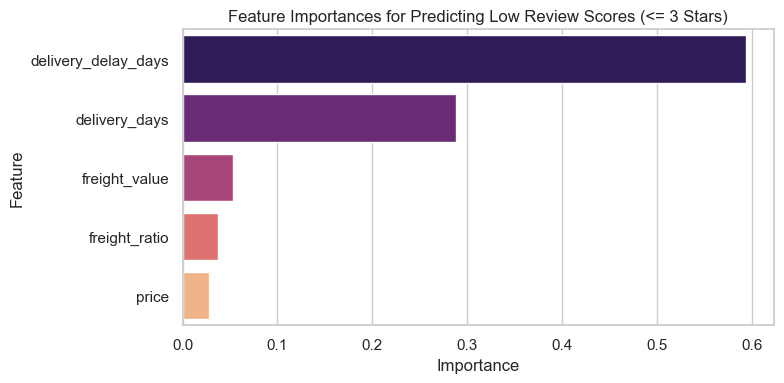

In [44]:
rev_ml = orders[orders['order_status'] == 'delivered'].merge(order_reviews, on='order_id').merge(order_items, on='order_id')
rev_ml['delivery_days'] = (rev_ml['order_delivered_customer_date'] - rev_ml['order_purchase_timestamp']).dt.total_seconds() / 86400
rev_ml['delivery_delay_days'] = (rev_ml['order_delivered_customer_date'] - rev_ml['order_estimated_delivery_date']).dt.total_seconds() / 86400
rev_ml['freight_ratio'] = rev_ml['freight_value'] / (rev_ml['price'] + rev_ml['freight_value'])
rev_ml['is_low_score'] = (rev_ml['review_score'] <= 3).astype(int)

features_rev = ['delivery_days', 'delivery_delay_days', 'price', 'freight_value', 'freight_ratio']
X_rev = rev_ml[features_rev].dropna()
y_rev = rev_ml.loc[X_rev.index, 'is_low_score']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)
clf_rev = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42)
clf_rev.fit(X_tr_r, y_tr_r)

imp_rev = pd.Series(clf_rev.feature_importances_, index=X_rev.columns).sort_values(ascending=False).reset_index()
imp_rev.columns = ['feature', 'importance']

plt.figure(figsize=(8, 4))
sns.barplot(data=imp_rev, x='importance', y='feature', palette='magma', hue='feature', legend=False)
plt.title('Feature Importances for Predicting Low Review Scores (<= 3 Stars)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 27. Churn Prediction — predicting repeat purchase likelihood.


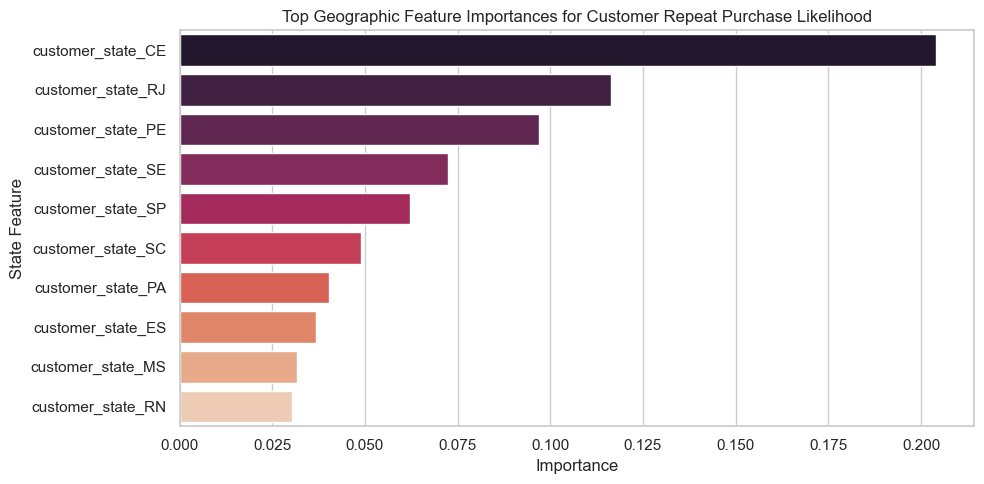

In [45]:
cust_churn = cust_orders_df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max')
).reset_index()

cust_churn['is_repeat'] = (cust_churn['total_orders'] > 1).astype(int)
cust_churn_geo = cust_churn.merge(customers.groupby('customer_unique_id')['customer_state'].first().reset_index(), on='customer_unique_id')

X_churn = pd.get_dummies(cust_churn_geo[['customer_state']], drop_first=True)
y_churn = cust_churn_geo['is_repeat']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)
clf_churn = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=42)
clf_churn.fit(X_tr_c, y_tr_c)

imp_churn = pd.Series(clf_churn.feature_importances_, index=X_churn.columns).sort_values(ascending=False).head(10).reset_index()
imp_churn.columns = ['feature', 'importance']

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_churn, x='importance', y='feature', palette='rocket', hue='feature', legend=False)
plt.title('Top Geographic Feature Importances for Customer Repeat Purchase Likelihood')
plt.xlabel('Importance')
plt.ylabel('State Feature')
plt.tight_layout()
plt.show()


## Market Structure & Competition


### 28. Market Concentration (Herfindahl-Hirschman Index - HHI) per Category.


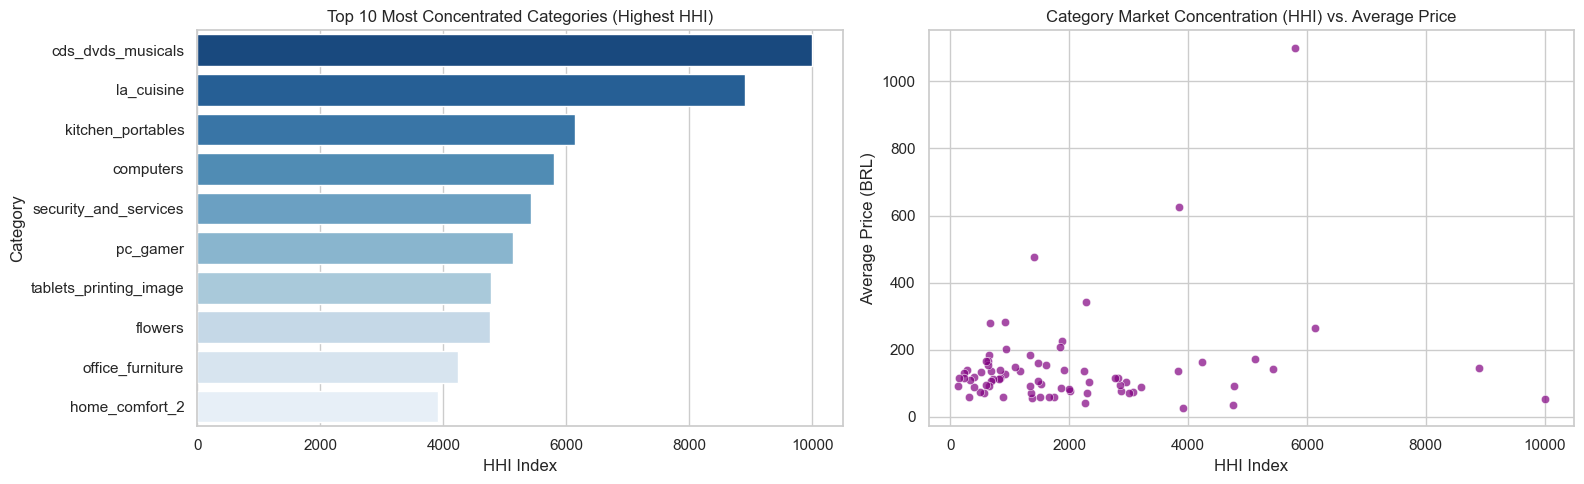

In [46]:
cat_seller_sales = order_items.merge(products, on='product_id').groupby(['product_category_name_english', 'seller_id'])['price'].sum().reset_index()
cat_total_sales = cat_seller_sales.groupby('product_category_name_english')['price'].sum().reset_index().rename(columns={'price': 'total_cat_price'})

cat_seller_sales = cat_seller_sales.merge(cat_total_sales, on='product_category_name_english')
cat_seller_sales['market_share'] = cat_seller_sales['price'] / cat_seller_sales['total_cat_price']

hhi = cat_seller_sales.groupby('product_category_name_english')['market_share'].apply(lambda x: (x**2).sum() * 10000).reset_index().rename(columns={'market_share': 'hhi'})
cat_price_mean = order_items.merge(products, on='product_id').groupby('product_category_name_english')['price'].mean().reset_index().rename(columns={'price': 'avg_price'})
hhi_price = hhi.merge(cat_price_mean, on='product_category_name_english').sort_values(by='hhi', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=hhi_price.head(10), x='hhi', y='product_category_name_english', ax=axes[0], palette='Blues_r', hue='product_category_name_english', legend=False)
axes[0].set_title('Top 10 Most Concentrated Categories (Highest HHI)')
axes[0].set_xlabel('HHI Index')
axes[0].set_ylabel('Category')

sns.scatterplot(data=hhi_price, x='hhi', y='avg_price', ax=axes[1], alpha=0.7, color='purple')
axes[1].set_title('Category Market Concentration (HHI) vs. Average Price')
axes[1].set_xlabel('HHI Index')
axes[1].set_ylabel('Average Price (BRL)')

plt.tight_layout()
plt.show()


### 29. Price Dispersion within Category (Coefficient of Variation).


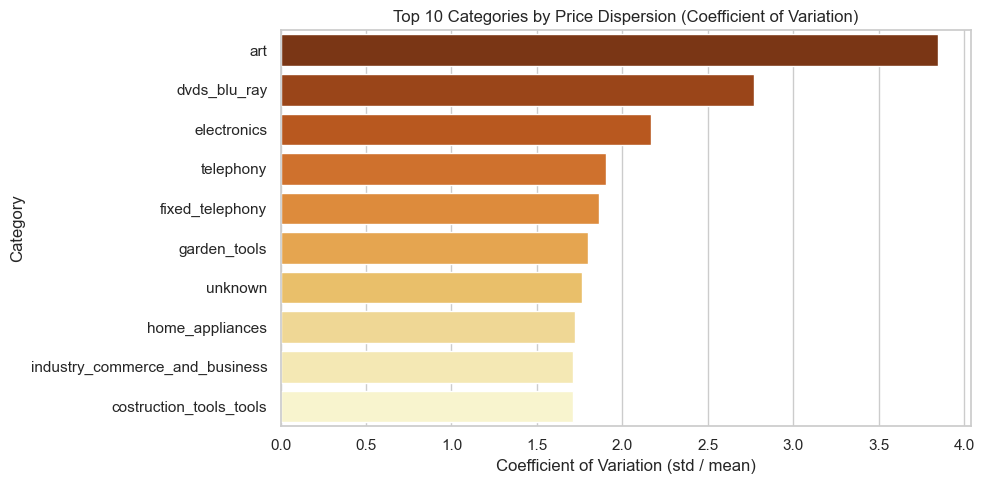

In [47]:
dispersion = order_items.merge(products, on='product_id').groupby('product_category_name_english')['price'].agg(['mean', 'std', 'count']).query('count > 50').reset_index()
dispersion['cv'] = dispersion['std'] / dispersion['mean']
dispersion_top = dispersion.sort_values(by='cv', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=dispersion_top, x='cv', y='product_category_name_english', palette='YlOrBr_r', hue='product_category_name_english', legend=False)
plt.title('Top 10 Categories by Price Dispersion (Coefficient of Variation)')
plt.xlabel('Coefficient of Variation (std / mean)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


### 30. Seller 'Specialists vs. Generalists' — performance comparison.


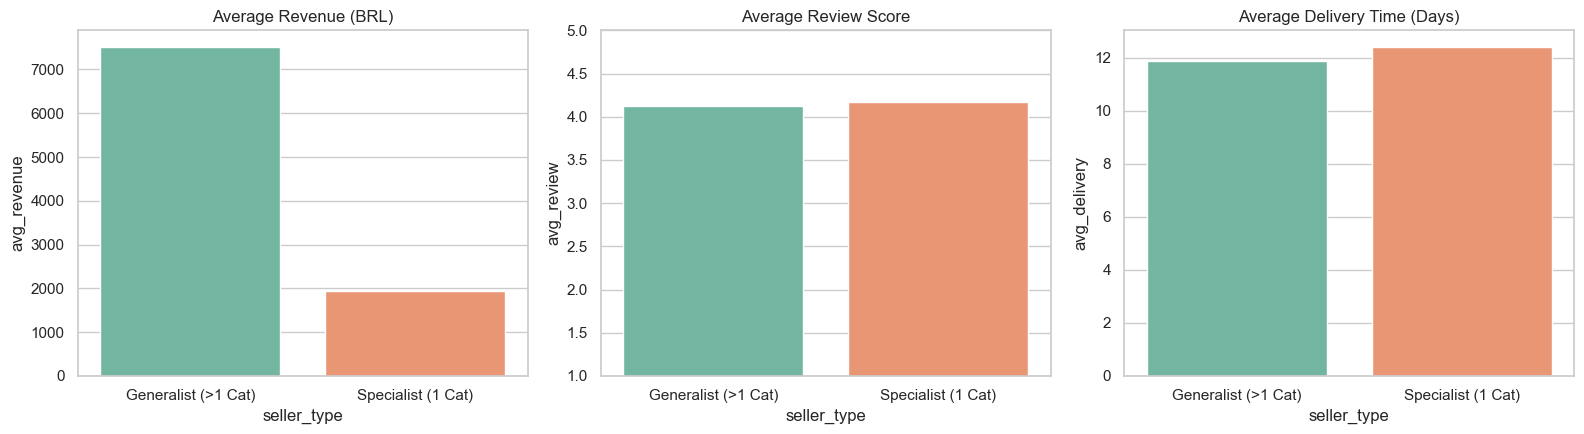

In [48]:
seller_perf = order_items.merge(products, on='product_id').groupby('seller_id').agg(
    n_categories=('product_category_name_english', 'nunique'),
    total_revenue=('price', 'sum')
).reset_index()
seller_rev_orders = orders[orders['order_status'] == 'delivered'].merge(order_items, on='order_id').merge(order_reviews, on='order_id', how='left')
seller_rev_orders['delivery_days'] = (seller_rev_orders['order_delivered_customer_date'] - seller_rev_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
seller_metrics = seller_rev_orders.groupby('seller_id').agg(
    avg_review=('review_score', 'mean'),
    avg_delivery=('delivery_days', 'mean')
).reset_index()

seller_perf = seller_perf.merge(seller_metrics, on='seller_id')
seller_perf['seller_type'] = seller_perf['n_categories'].apply(lambda x: 'Specialist (1 Cat)' if x == 1 else 'Generalist (>1 Cat)')
perf_summary = seller_perf.groupby('seller_type').agg(
    avg_revenue=('total_revenue', 'mean'),
    avg_review=('avg_review', 'mean'),
    avg_delivery=('avg_delivery', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=perf_summary, x='seller_type', y='avg_revenue', ax=axes[0], palette='Set2', hue='seller_type', legend=False)
axes[0].set_title('Average Revenue (BRL)')

sns.barplot(data=perf_summary, x='seller_type', y='avg_review', ax=axes[1], palette='Set2', hue='seller_type', legend=False)
axes[1].set_title('Average Review Score')
axes[1].set_ylim(1, 5)

sns.barplot(data=perf_summary, x='seller_type', y='avg_delivery', ax=axes[2], palette='Set2', hue='seller_type', legend=False)
axes[2].set_title('Average Delivery Time (Days)')

plt.tight_layout()
plt.show()


## Geography as a Driver


### 31. Distance Penalty Quantified — regression of distance vs. freight value.


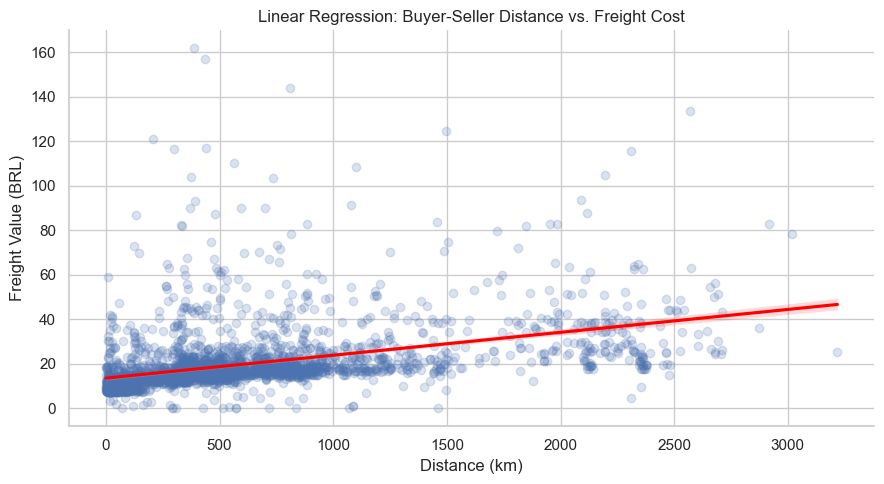

In [49]:
sns.lmplot(
    data=geo_penalty.sample(n=3000, random_state=42),
    x='distance_km',
    y='freight_value',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'},
    height=5,
    aspect=1.8
)
plt.title('Linear Regression: Buyer-Seller Distance vs. Freight Cost')
plt.xlabel('Distance (km)')
plt.ylabel('Freight Value (BRL)')
plt.tight_layout()
plt.show()


### 32. Underserved Regions — customer-to-seller ratio vs. delivery time.


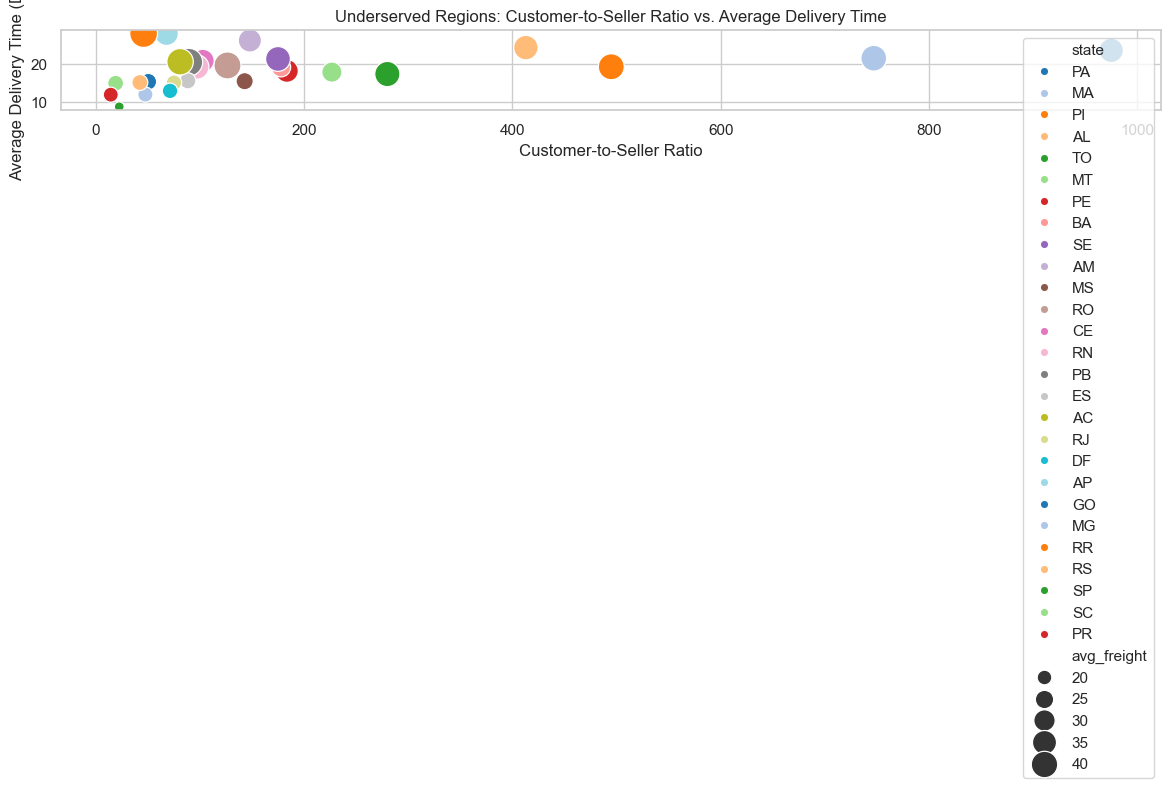

In [50]:
cust_per_state = customers['customer_state'].value_counts().reset_index()
cust_per_state.columns = ['state', 'n_customers']
seller_per_state = sellers['seller_state'].value_counts().reset_index()
seller_per_state.columns = ['state', 'n_sellers']

state_ratio = cust_per_state.merge(seller_per_state, on='state', how='left').fillna(1)
state_ratio['cust_seller_ratio'] = state_ratio['n_customers'] / state_ratio['n_sellers']

state_del_freight = orders[orders['order_status'] == 'delivered'].merge(customers, on='customer_id').merge(order_items, on='order_id')
state_del_freight['delivery_days'] = (state_del_freight['order_delivered_customer_date'] - state_del_freight['order_purchase_timestamp']).dt.total_seconds() / 86400
state_outcomes = state_del_freight.groupby('customer_state').agg(
    avg_delivery=('delivery_days', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index().rename(columns={'customer_state': 'state'})

underserved = state_ratio.merge(state_outcomes, on='state').sort_values(by='cust_seller_ratio', ascending=False)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=underserved, x='cust_seller_ratio', y='avg_delivery', size='avg_freight', hue='state', sizes=(50, 400), palette='tab20')
plt.title('Underserved Regions: Customer-to-Seller Ratio vs. Average Delivery Time')
plt.xlabel('Customer-to-Seller Ratio')
plt.ylabel('Average Delivery Time (Days)')
plt.tight_layout()
plt.show()


### 33. Inter-state vs. Intra-state Orders — outcomes analysis.


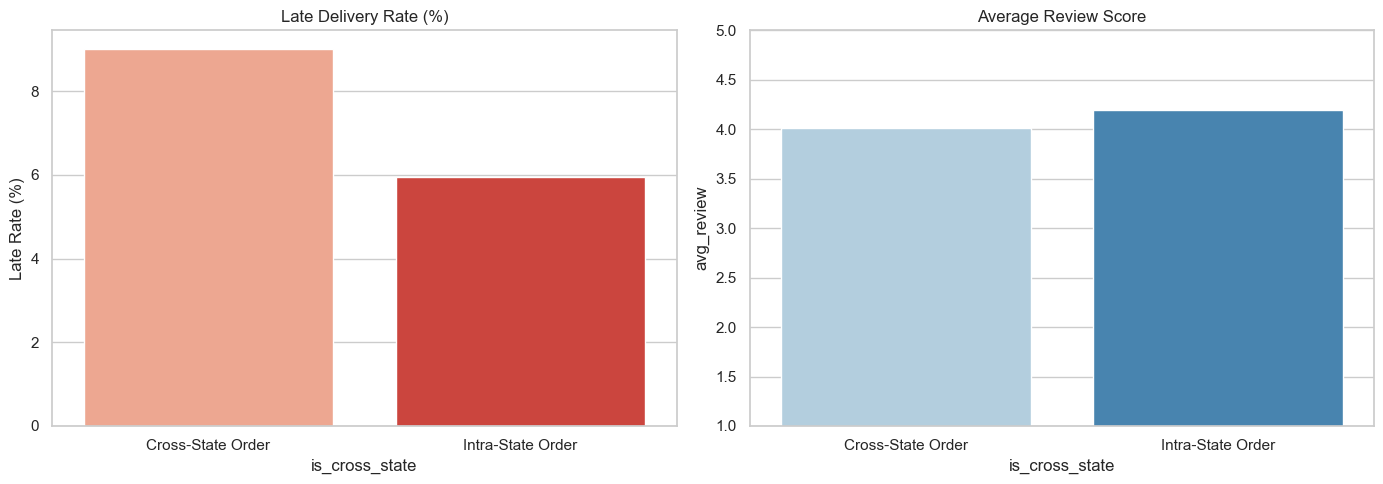

In [51]:
border_df = orders[orders['order_status'] == 'delivered'].merge(customers, on='customer_id').merge(order_items, on='order_id').merge(sellers, on='seller_id').merge(order_reviews, on='order_id', how='left')
border_df['is_cross_state'] = (border_df['customer_state'] != border_df['seller_state']).map({True: 'Cross-State Order', False: 'Intra-State Order'})
border_df['delivery_delay_days'] = (border_df['order_delivered_customer_date'] - border_df['order_estimated_delivery_date']).dt.total_seconds() / 86400
border_df['is_late'] = (border_df['delivery_delay_days'] > 0).astype(int)

border_outcomes = border_df.groupby('is_cross_state').agg(
    late_rate=('is_late', lambda x: x.mean() * 100),
    avg_review=('review_score', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=border_outcomes, x='is_cross_state', y='late_rate', ax=axes[0], palette='Reds', hue='is_cross_state', legend=False)
axes[0].set_title('Late Delivery Rate (%)')
axes[0].set_ylabel('Late Rate (%)')

sns.barplot(data=border_outcomes, x='is_cross_state', y='avg_review', ax=axes[1], palette='Blues', hue='is_cross_state', legend=False)
axes[1].set_title('Average Review Score')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()


## Time-Based & Anomaly Detection


### 34. Decompose Revenue Time Series — trend and seasonality decomposition.


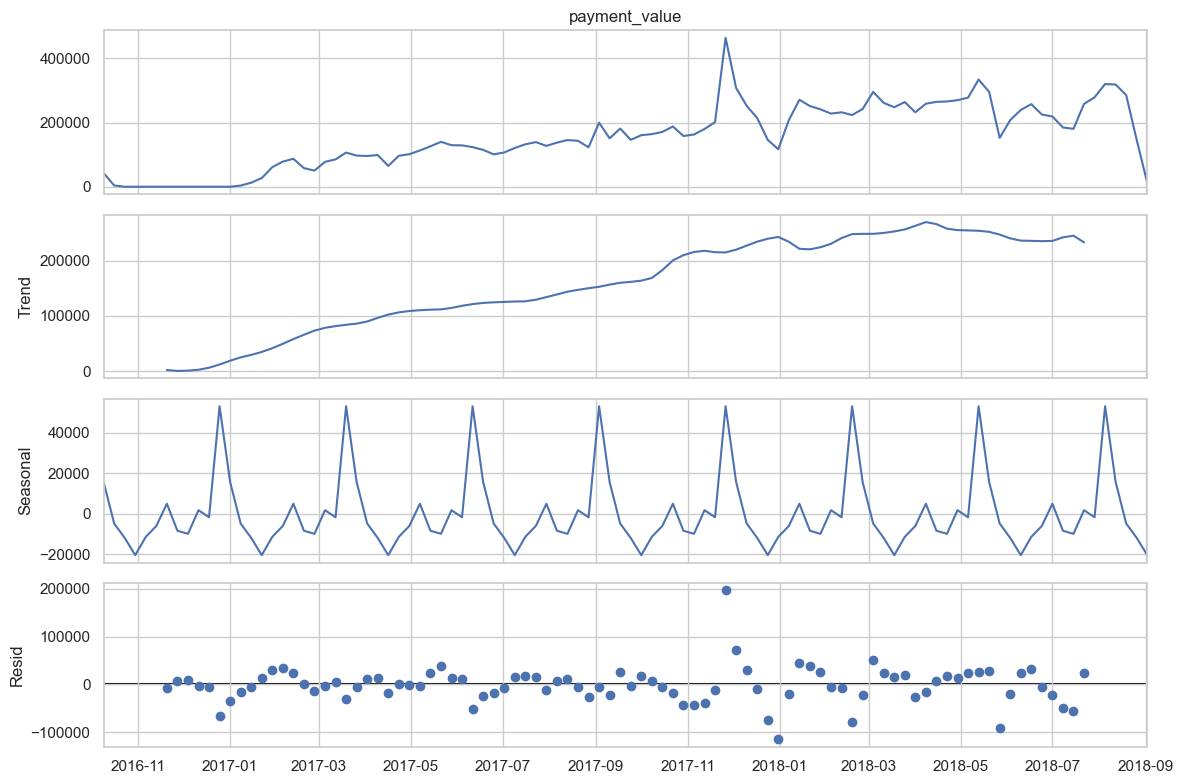

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose

weekly_ts = orders[orders['order_status'] == 'delivered'].merge(order_payments, on='order_id').set_index('order_purchase_timestamp').resample('W')['payment_value'].sum().dropna()

decomp = seasonal_decompose(weekly_ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


### 35. Anomalous Days / Weeks — cancellation rate anomaly detection.


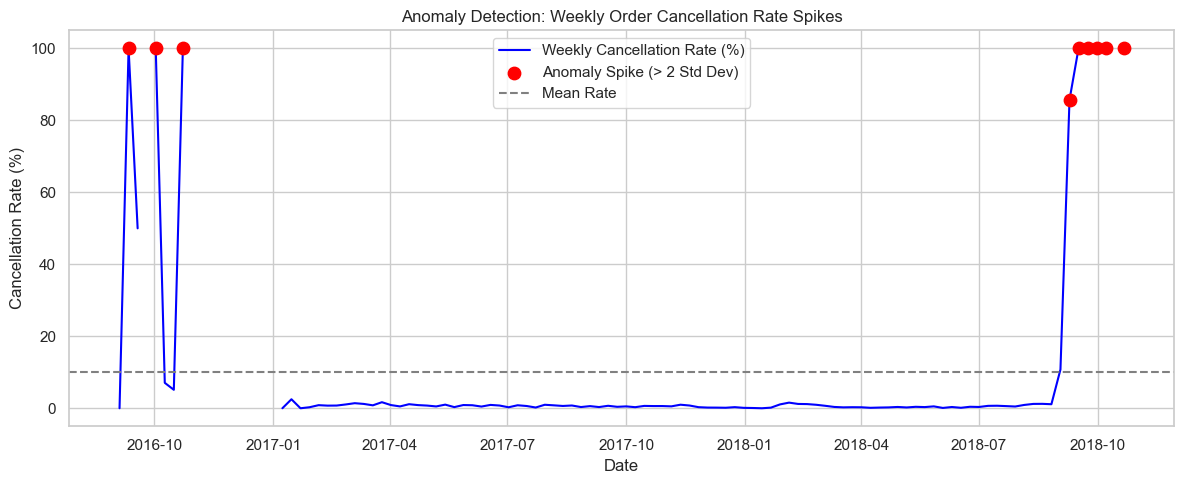

In [53]:
weekly_orders = orders.set_index('order_purchase_timestamp').resample('W').agg(
    total_orders=('order_id', 'count'),
    canceled_orders=('order_status', lambda x: (x == 'canceled').sum())
)
weekly_orders['cancel_rate'] = (weekly_orders['canceled_orders'] / weekly_orders['total_orders']) * 100
mean_rate = weekly_orders['cancel_rate'].mean()
std_rate = weekly_orders['cancel_rate'].std()
weekly_orders['is_anomaly'] = (weekly_orders['cancel_rate'] > mean_rate + 2 * std_rate)

plt.figure(figsize=(12, 5))
plt.plot(weekly_orders.index, weekly_orders['cancel_rate'], label='Weekly Cancellation Rate (%)', color='blue')
anomaly_pts = weekly_orders[weekly_orders['is_anomaly']]
plt.scatter(anomaly_pts.index, anomaly_pts['cancel_rate'], color='red', s=80, zorder=5, label='Anomaly Spike (> 2 Std Dev)')
plt.axhline(mean_rate, color='gray', linestyle='--', label='Mean Rate')
plt.title('Anomaly Detection: Weekly Order Cancellation Rate Spikes')
plt.xlabel('Date')
plt.ylabel('Cancellation Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()


### 36. Payment Installment Trends Over Time — average installment count evolution.


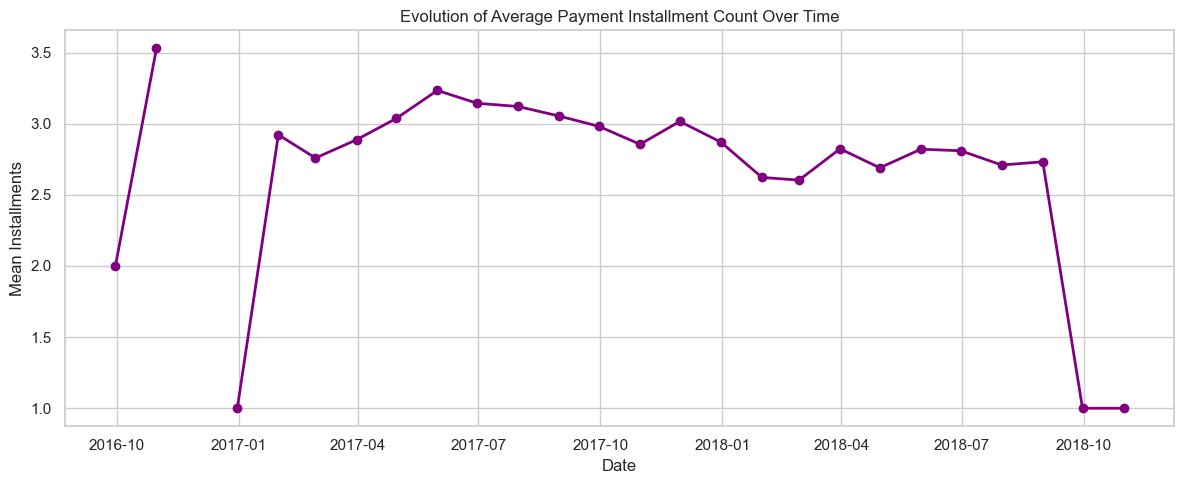

In [54]:
monthly_installments = orders.merge(order_payments, on='order_id').set_index('order_purchase_timestamp').resample('ME')['payment_installments'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_installments.index, monthly_installments.values, marker='o', color='purple', linewidth=2)
plt.title('Evolution of Average Payment Installment Count Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Installments')
plt.tight_layout()
plt.show()


## Text & Review Analytics


### 37. Sentiment vs. Star Rating Mismatch — review comment vs. rating alignment.


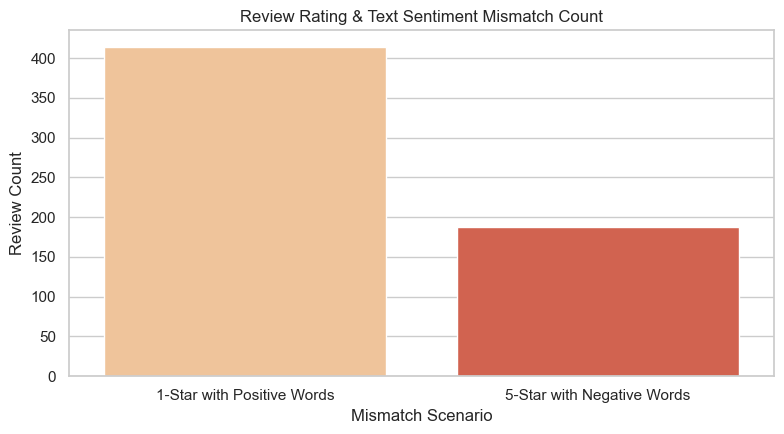

In [55]:
rev_text = order_reviews.dropna(subset=['review_comment_message']).copy()
pos_keywords = ['excelente', 'otimo', 'bom', 'perfeito', 'recomendo', 'maravihloso']
neg_keywords = ['pessimo', 'ruim', 'demora', 'atraso', 'nao recebi', 'defeito', 'horrivel']

rev_text['has_pos'] = rev_text['review_comment_message'].str.lower().apply(lambda x: any(w in x for w in pos_keywords))
rev_text['has_neg'] = rev_text['review_comment_message'].str.lower().apply(lambda x: any(w in x for w in neg_keywords))

mismatch_5star = rev_text[(rev_text['review_score'] == 5) & rev_text['has_neg']].shape[0]
mismatch_1star = rev_text[(rev_text['review_score'] == 1) & rev_text['has_pos']].shape[0]

mismatch_df = pd.DataFrame({
    'type': ['1-Star with Positive Words', '5-Star with Negative Words'],
    'count': [mismatch_1star, mismatch_5star]
})

plt.figure(figsize=(8, 4.5))
sns.barplot(data=mismatch_df, x='type', y='count', palette='OrRd', hue='type', legend=False)
plt.title('Review Rating & Text Sentiment Mismatch Count')
plt.xlabel('Mismatch Scenario')
plt.ylabel('Review Count')
plt.tight_layout()
plt.show()


### 38. Top Words in 1-Star vs. 5-Star Reviews.


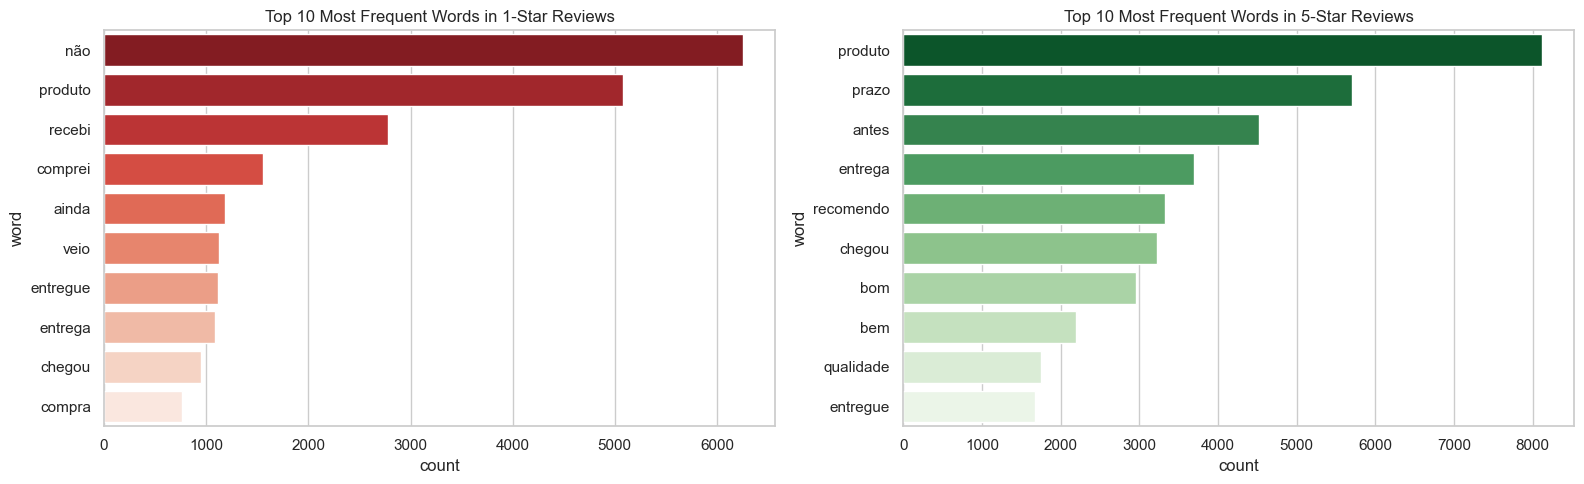

In [56]:
from collections import Counter
import re

stopwords = set(['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'nao', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'quando', 'muito', 'nos', 'já', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'você', 'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'numa', 'cujo', 'pelos', 'elas', 'qual', 'nós', 'lhe', 'deles', 'essas', 'esses', 'pelas', 'este', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'dela', 'delas', 'esta', 'estes', 'estas', 'aquele', 'aquela', 'aqueles', 'aquelas', 'isto', 'aquilo', 'estou', 'está', 'estamos', 'estão', 'estive', 'esteve', 'estivemos', 'estiveram', 'estava', 'estávamos', 'estavam', 'estivera', 'estivéramos', 'esteja', 'estejamos', 'estejam', 'estivesse', 'estivéssemos', 'estivessem', 'estiver', 'estivermos', 'estiverem', 'hei', 'há', 'havemos', 'hão', 'houve', 'houvemos', 'houveram', 'houvera', 'houvéramos', 'haja', 'hajamos', 'hajam', 'houvesse', 'houvéssemos', 'houvessem', 'houver', 'houvermos', 'houverem', 'houverei', 'houverá', 'houveremos', 'houverão', 'houveria', 'houveríamos', 'houveriam', 'sou', 'somos', 'são', 'era', 'éramos', 'eram', 'fui', 'foi', 'fomos', 'foram', 'fora', 'fôramos', 'seja', 'sejamos', 'sejam', 'fosse', 'fôssemos', 'fossem', 'for', 'formos', 'forem', 'serei', 'será', 'seremos', 'serão', 'seria', 'seríamos', 'seriam', 'tenho', 'tem', 'temos', 'tém', 'tinha', 'tínhamos', 'tinham', 'tive', 'teve', 'tivemos', 'tiveram', 'tivera', 'tivéramos', 'tenha', 'tenhamos', 'tenham', 'tivesse', 'tivéssemos', 'tivessem', 'tiver', 'tivermos', 'tiverem', 'terei', 'terá', 'teremos', 'terão', 'teria', 'teríamos', 'teriam'])

def get_top_words(texts, top_n=10):
    words = []
    for txt in texts:
        tokens = re.findall(r'\b[a-zA-Záéíóúãõçâêô]+\b', str(txt).lower())
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    return pd.DataFrame(Counter(words).most_common(top_n), columns=['word', 'count'])

text_1star = order_reviews[order_reviews['review_score'] == 1]['review_comment_message'].dropna()
text_5star = order_reviews[order_reviews['review_score'] == 5]['review_comment_message'].dropna()

top_1star = get_top_words(text_1star)
top_5star = get_top_words(text_5star)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top_1star, x='count', y='word', ax=axes[0], palette='Reds_r', hue='word', legend=False)
axes[0].set_title('Top 10 Most Frequent Words in 1-Star Reviews')

sns.barplot(data=top_5star, x='count', y='word', ax=axes[1], palette='Greens_r', hue='word', legend=False)
axes[1].set_title('Top 10 Most Frequent Words in 5-Star Reviews')

plt.tight_layout()
plt.show()
